In [52]:
import pypsa

n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")  # adjust filename if needed

annual_demand_mwh = n.loads_t.p_set.sum().sum()
print(annual_demand_mwh / 1e6, "TWh")

annual_demand_mwh = (
    n.loads_t.p_set
    .multiply(n.snapshot_weightings.objective, axis=0)
    .sum()
    .sum()
)
print(annual_demand_mwh / 1e6, "TWh")

print(n.snapshot_weightings.objective)  # should be ~156 hours per snapshot (8760h / 56 snapshots)



INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores


0.041187780690876565 TWh
6.44294569378712 TWh
snapshot
2013-01-01 00:00:00    156.428571
2013-01-01 03:00:00    156.428571
2013-01-01 06:00:00    156.428571
2013-01-01 09:00:00    156.428571
2013-01-01 12:00:00    156.428571
2013-01-01 15:00:00    156.428571
2013-01-01 18:00:00    156.428571
2013-01-01 21:00:00    156.428571
2013-01-02 00:00:00    156.428571
2013-01-02 03:00:00    156.428571
2013-01-02 06:00:00    156.428571
2013-01-02 09:00:00    156.428571
2013-01-02 12:00:00    156.428571
2013-01-02 15:00:00    156.428571
2013-01-02 18:00:00    156.428571
2013-01-02 21:00:00    156.428571
2013-01-03 00:00:00    156.428571
2013-01-03 03:00:00    156.428571
2013-01-03 06:00:00    156.428571
2013-01-03 09:00:00    156.428571
2013-01-03 12:00:00    156.428571
2013-01-03 15:00:00    156.428571
2013-01-03 18:00:00    156.428571
2013-01-03 21:00:00    156.428571
2013-01-04 00:00:00    156.428571
2013-01-04 03:00:00    156.428571
2013-01-04 06:00:00    156.428571
2013-01-04 09:00:00    156.

In [14]:
import pypsa

n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")  # adjust path

print(n)
print(n.generators.groupby("carrier").p_nom_opt.sum())
print(n.storage_units.groupby("carrier").p_nom_opt.sum())
print(n.stores.groupby("carrier").e_nom_opt.sum())
print(n.objective)

INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores


PyPSA Network
Components:
 - Bus: 39
 - Carrier: 20
 - Generator: 86
 - GlobalConstraint: 1
 - Line: 12
 - Link: 52
 - Load: 13
 - Store: 26
Snapshots: 56
carrier
CCGT             6.460000e+02
coal             1.550000e+02
load shedding    1.104051e+03
offwind-ac       3.152919e-11
offwind-dc       1.739261e-11
oil              6.089600e+02
onwind           1.059783e+03
solar            1.343322e+03
Name: p_nom_opt, dtype: float64
Series([], Name: p_nom_opt, dtype: float64)
carrier
H2         2.562478e-08
battery    1.021359e-09
Name: e_nom_opt, dtype: float64
179332012.67236966


In [15]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator Coal                       155.00000           155.00000   
          Combined-Cycle Gas         646.00000           646.00000   
          Load shedding             1104.05136          1104.05136   
          Offshore Wind (AC)           0.00000             0.00000   
          Oil                        608.96000           608.96000   
          Onshore Wind              1059.78278           208.00000   
          Solar                     1343.32204           400.30000   
Line      Ac                        6535.46071          6535.46071   
Link      H2 electrolysis              0.00000             0.00000   
          H2 fuel cell                 0.00000             0.00000   
          battery charger              0.00000             0.00000   
Load      -                            0.00000             0.00000   
Store     Battery Storage              0.00000             0.00000   
          H2                           0.00000             0.00000   

                                    Supply    Withdrawal  Energy Balance  \
Generator Coal                7.598309e+05  0.000000e+00    7.598309e+05   
          Combined-Cycle Gas  6.985734e+05  0.000000e+00    6.985734e+05   
          Load shedding       0.000000e+00  0.000000e+00    0.000000e+00   
          Offshore Wind (AC)  0.000000e+00  0.000000e+00    0.000000e+00   
          Oil                 0.000000e+00  0.000000e+00    0.000000e+00   
          Onshore Wind        3.651250e+06  0.000000e+00    3.651250e+06   
          Solar               1.333291e+06  0.000000e+00    1.333291e+06   
Line      Ac                  1.091153e+07  1.091153e+07    0.000000e+00   
Link      H2 electrolysis     0.000000e+00  0.000000e+00    0.000000e+00   
          H2 fuel cell        0.000000e+00  0.000000e+00    0.000000e+00   
          battery charger     0.000000e+00  0.000000e+00    0.000000e+00   
Load      -                   0.000000e+00  6.442946e+06   -6.442946e+06   
Store     Battery Storage     0.000000e+00  0.000000e+00    0.000000e+00   
          H2                  0.000000e+00  0.000000e+00    0.000000e+00   

                              Transmission  Capacity Factor   Curtailment  \
Generator Coal                     0.00000         0.559604  5.979691e+05   
          Combined-Cycle Gas       0.00000         0.123446  4.960387e+06   
          Load shedding            0.00000         0.000000  9.671490e+06   
          Offshore Wind (AC)       0.00000         0.000000  0.000000e+00   
          Oil                      0.00000         0.000000  5.334490e+06   
          Onshore Wind             0.00000         0.393297  4.700207e+05   
          Solar                    0.00000         0.113303  6.367386e+05   
Line      Ac                  119463.65415         0.190592  0.000000e+00   
Link      H2 electrolysis          0.00000         0.000000  0.000000e+00   
          H2 fuel cell             0.00000         0.000000  0.000000e+00   
          battery charger          0.00000         0.000000  0.000000e+00   
Load      -                        0.00000              NaN  0.000000e+00   
Store     Battery Storage          0.00000         0.000000  0.000000e+00   
          H2                       0.00000         0.000000  0.000000e+00   

                              Capital Expenditure  Operational Expenditure  \
Generator Coal                       5.226724e+07             2.287826e+07   
          Combined-Cycle Gas         6.769306e+07             3.270257e+07   
          Load shedding              0.000000e+00             1.000000e-05   
          Offshore Wind (AC)         1.000000e-05             0.000000e+00   
          Oil                        2.441113e+07             0.000000e+00   
          Onshore Wind               1.077207e+08             8.894576e+04   
          Solar                      5.278782e+07             2.607571e+04   
Line      Ac                         4.606890e+07         

/Users/william/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x3299f3d50>,
 <matplotlib.collections.LineCollection at 0x31807e910>)

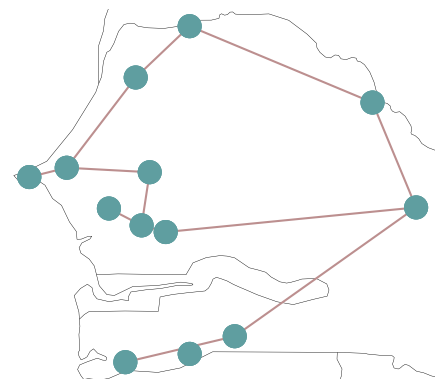

In [16]:
n.plot()

In [17]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("component '{}' has {} active entries".format(c.name, len(c.df)))

component 'Bus' has 39 active entries
component 'Carrier' has 20 active entries
component 'GlobalConstraint' has 1 active entries
component 'Line' has 12 active entries
component 'LineType' has 35 active entries
component 'TransformerType' has 14 active entries
component 'Link' has 52 active entries
component 'Load' has 13 active entries
component 'Generator' has 86 active entries
component 'Store' has 26 active entries


In [18]:
n.snapshots[:10]
len(n.snapshots)

56

In [19]:
n.lines.head()

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,carrier,type,s_max_pu,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,0.296053,380.0,SN.10_1_AC,SN.8_1_AC,119.182096,False,MULTILINESTRING ((-15.46652940000003 16.511098...,AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,0.296053,380.0,SN.10_1_AC,SN.9_1_AC,313.332167,False,"MULTILINESTRING ((-15.4664 16.5112, -15.466281...",AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
10,0.296053,380.0,SN.3_1_AC,SN.5_1_AC,58.721737,False,MULTILINESTRING ((-16.4160888 14.3661244999999...,AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
11,0.296053,380.0,SN.4_1_AC,SN.5_1_AC,39.736143,False,"MULTILINESTRING ((-16.0316 14.1676, -16.031515...",AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
2,0.296053,380.0,SN.12_1_AC,SN.4_1_AC,399.007217,False,MULTILINESTRING ((-13.729777299999999 13.77427...,AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [20]:
n.generators.head()

,carrier,bus,p_nom,p_nom_extendable,p_nom_min,p_nom_max,efficiency,marginal_cost,capital_cost,build_year,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
SN.10_1_AC onwind,onwind,SN.10_1_AC,0.0,True,0.0,23851.571671,1.00,0.024920,101644.123324,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
SN.10_1_AC solar,solar,SN.10_1_AC,20.0,True,20.0,37714.206770,1.00,0.020793,39296.472708,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
SN.11_1_AC onwind,onwind,SN.11_1_AC,0.0,True,0.0,11522.658767,1.00,0.024380,101644.123324,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
SN.11_1_AC solar,solar,SN.11_1_AC,60.0,True,60.0,4735.286330,1.00,0.019412,39296.472708,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
SN.12_1_AC oil,oil,SN.12_1_AC,71.0,False,71.0,71.000000,0.35,157.533905,40086.594536,2008,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [21]:
n.storage_units.head()

attribute,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge,cyclic_state_of_charge_per_period,max_hours,efficiency_store,efficiency_dispatch,standing_loss,inflow,p_nom_opt
StorageUnit,,,,,,,,,,,,,,,,,,,,,


In [22]:
n.loads.head()

,bus,carrier,type,p_set,q_set,sign
Load,,,,,,
SN.10_1_AC,SN.10_1_AC,,,0.0,0.0,-1.0
SN.11_1_AC,SN.11_1_AC,,,0.0,0.0,-1.0
SN.12_1_AC,SN.12_1_AC,,,0.0,0.0,-1.0
SN.13_1_AC,SN.13_1_AC,,,0.0,0.0,-1.0
SN.14_1_AC,SN.14_1_AC,,,0.0,0.0,-1.0


In [23]:
n.loads_t.p_set.head()

Load,SN.10_1_AC,SN.11_1_AC,SN.12_1_AC,SN.13_1_AC,SN.14_1_AC,SN.1_1_AC,SN.2_1_AC,SN.3_1_AC,SN.4_1_AC,SN.5_1_AC,SN.7_1_AC,SN.8_1_AC,SN.9_1_AC
snapshot,,,,,,,,,,,,,
2013-01-01 00:00:00,36.848104,20.749608,29.164365,73.610385,26.478571,121.514135,56.918484,33.099943,27.001287,44.598013,26.761772,34.946041,24.134657
2013-01-01 03:00:00,39.128757,22.033872,30.969446,78.166380,28.117419,129.035054,60.441361,35.148610,28.672488,47.358334,28.418148,37.108969,25.628432
2013-01-01 06:00:00,49.058022,27.625160,38.828214,98.001784,35.252460,161.778829,75.778885,44.067878,35.948383,59.375927,35.629502,46.525695,32.131871
2013-01-01 09:00:00,53.649736,30.210808,42.462443,107.174516,38.552006,176.920941,82.871608,48.192526,39.313066,64.933371,38.964339,50.880388,35.139337
2013-01-01 12:00:00,53.341724,30.037364,42.218659,106.559211,38.330673,175.905210,82.395829,47.915846,39.087363,64.560579,38.740638,50.588276,34.937597


<Axes: xlabel='snapshot'>

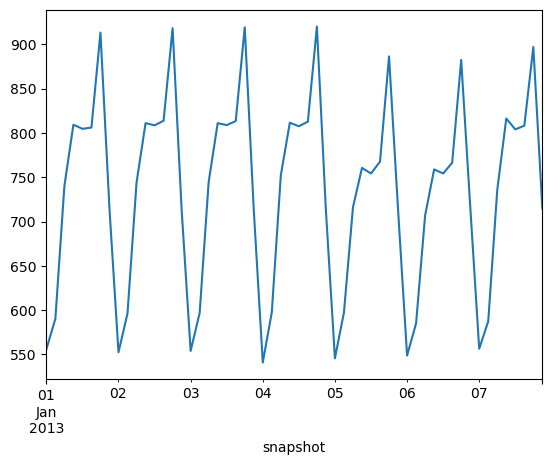

In [24]:
n.loads_t.p_set.sum(axis=1).plot()

In [25]:
n.generators_t.p_max_pu.loc["2013-01", "ITO 0 solar"].plot()

KeyError: 'ITO 0 solar'

In [ ]:
n.objective/1e9 #billion euros per year, system cost

0.19785959134354056

: 

In [27]:
(n.lines.s_nom_opt - n.lines.s_nom).head(5) # transmission expansion in MW

Line
0     1.762146e-12
1     6.821210e-13
10    3.524292e-12
11    5.172751e-12
2     6.252776e-13
dtype: float64

<Axes: xlabel='carrier'>

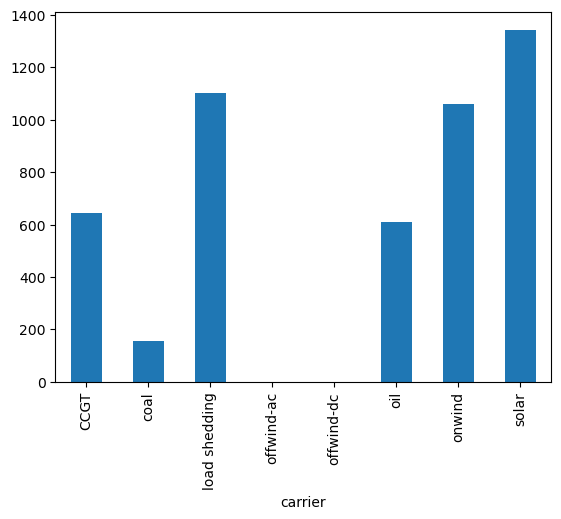

In [26]:
n.generators.groupby("carrier").p_nom_opt.sum().plot.bar()

In [ ]:
n.generators.groupby("carrier").p_nom_opt.sum() / 1e3

carrier
CCGT             6.460000e-01
coal             1.550000e-01
load shedding    1.104051e+00
offwind-ac       3.871512e-13
offwind-dc       1.002819e-13
oil              6.089600e-01
onwind           1.027504e+00
solar            1.473948e+00
Name: p_nom_opt, dtype: float64

: 

<Axes: xlabel='snapshot'>

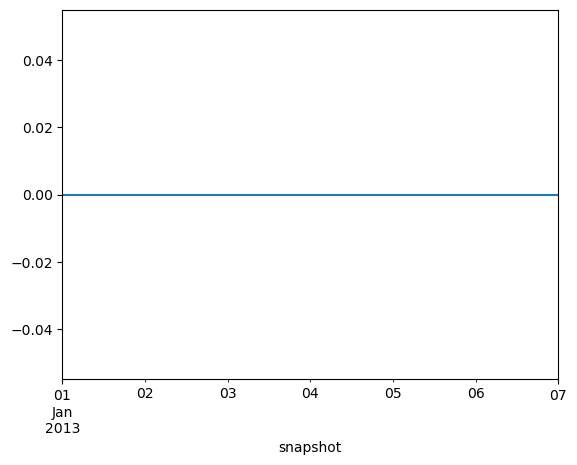

In [28]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample("D").mean() / 1e6).plot()

<Axes: xlabel='snapshot'>

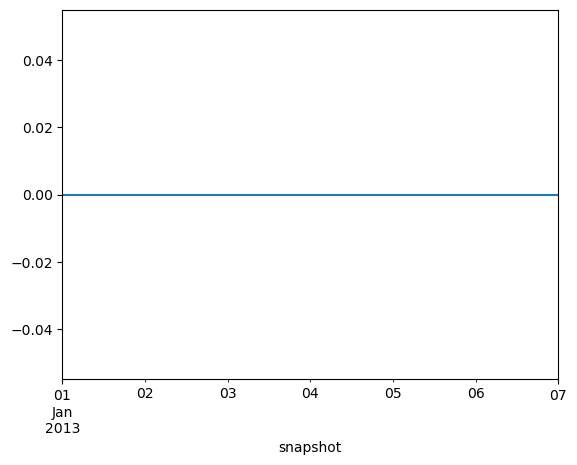

In [29]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample("D").mean() / 1e6).plot()

In [30]:
(n.storage_units_t.state_of_charge["2013-01"].filter(like="battery", axis=1).sum(axis=1).plot())

KeyError: '2013-01'

# Plotting networks

In [32]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [33]:
loading = (n.lines_t.p0.abs().mean().sort_index() / (n.lines.s_nom_opt*n.lines.s_max_pu).sort_index()).fillna(0.)

/Users/william/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


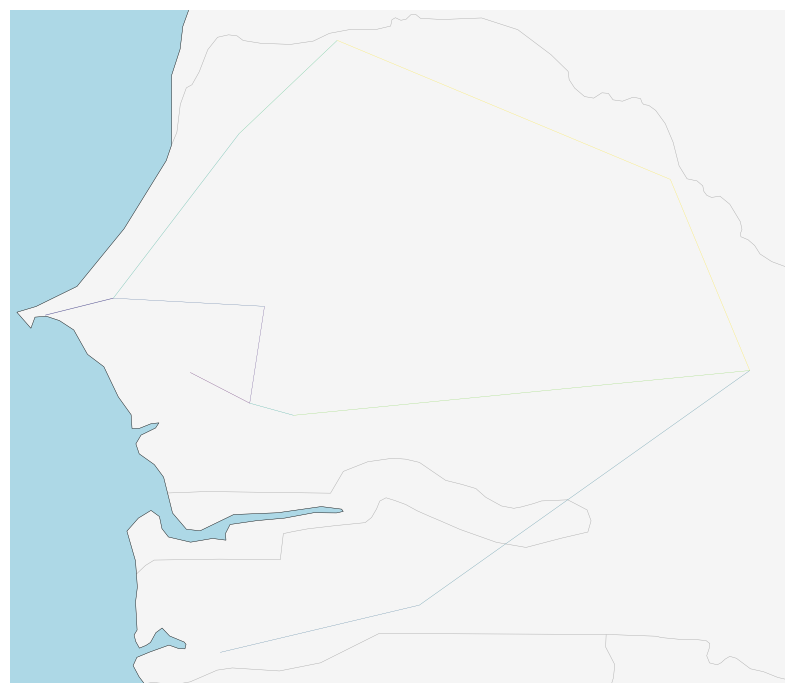

In [34]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
n.plot(ax = ax, bus_colors='gray', branch_components=["Line"], line_widths = n.lines.s_nom_opt/3e3, line_colors=loading, line_cmap="viridis", color_geomap=True, bus_sizes=0)

ax.axis('off');

INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores


snapshot
2013-01-01 00:00:00    555.825366
2013-01-01 03:00:00    590.227270
2013-01-01 06:00:00    740.002610
2013-01-01 09:00:00    809.265085
2013-01-01 12:00:00    804.618969
dtype: float64
count     56.000000
mean     735.496084
std      110.913009
min      540.900475
25%      679.552029
50%      753.166877
75%      809.702783
max      920.042799
dtype: float64


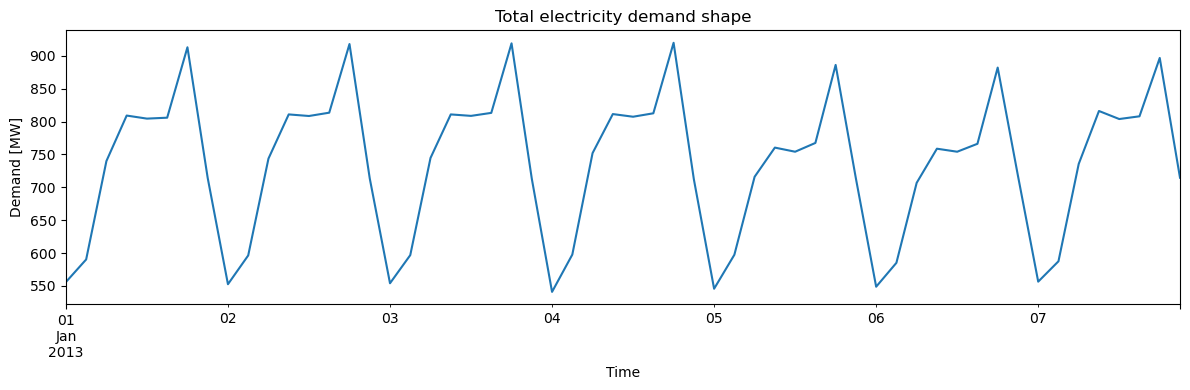

In [2]:
import pypsa
import matplotlib.pyplot as plt

# Choose your network file
n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")

# Hourly demand per bus
demand_by_bus = n.loads_t.p_set

# Total system demand per hour
total_demand = demand_by_bus.sum(axis=1)

print(total_demand.head())
print(total_demand.describe())

total_demand.plot(figsize=(12, 4))
plt.ylabel("Demand [MW]")
plt.xlabel("Time")
plt.title("Total electricity demand shape")
plt.tight_layout()
plt.show()

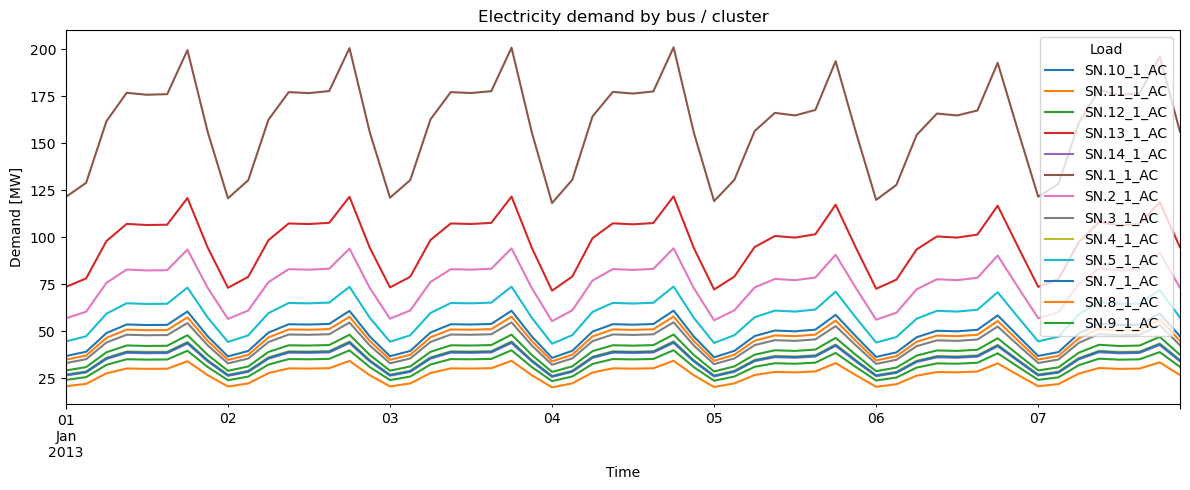

In [3]:
demand_by_bus.plot(figsize=(12, 5))
plt.ylabel("Demand [MW]")
plt.xlabel("Time")
plt.title("Electricity demand by bus / cluster")
plt.tight_layout()
plt.show()

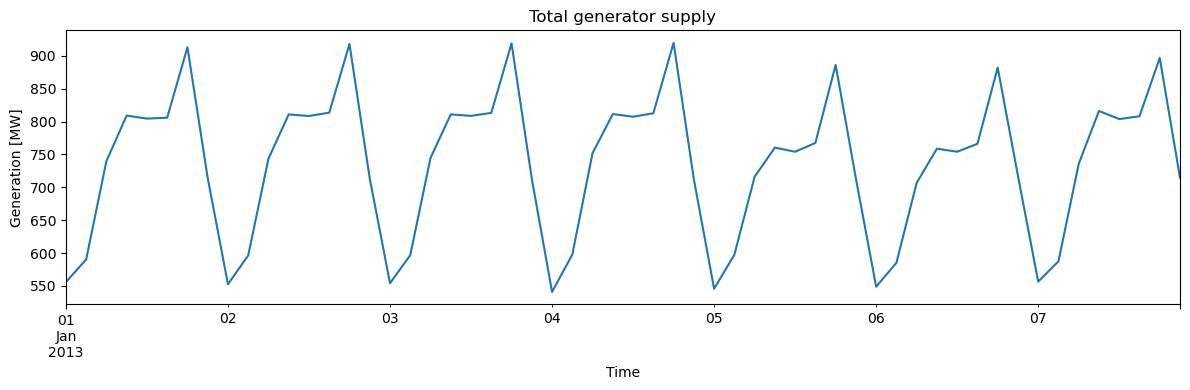

In [38]:
import pypsa
import matplotlib.pyplot as plt



# Generator dispatch
gen_supply = n.generators_t.p

# Total generator supply per hour
total_gen_supply = gen_supply.sum(axis=1)

total_gen_supply.plot(figsize=(12, 4))
plt.ylabel("Generation [MW]")
plt.xlabel("Time")
plt.title("Total generator supply")
plt.tight_layout()
plt.show()

carrier                      CCGT          coal  load shedding    offwind-ac  \
snapshot                                                                       
2013-01-01 00:00:00  2.376370e-12  3.694632e-12   7.221599e-15  9.227642e-12   
2013-01-01 03:00:00  2.376316e-12  3.694540e-12   7.221582e-15  9.152221e-12   
2013-01-01 06:00:00  2.376432e-12  3.694768e-12   7.221526e-15  1.005495e-11   
2013-01-01 09:00:00  2.376215e-12  3.695098e-12   7.221383e-15  1.078374e-11   
2013-01-01 12:00:00  2.375791e-12  3.694306e-12   7.221469e-15  6.705637e-12   

carrier                offwind-dc           oil      onwind       solar  
snapshot                                                                 
2013-01-01 00:00:00  5.111225e-12  1.764819e-12  555.825366    0.000000  
2013-01-01 03:00:00  4.924450e-12  1.764835e-12  590.227270    0.000000  
2013-01-01 06:00:00  5.290799e-12  1.764809e-12  740.002610    0.000000  
2013-01-01 09:00:00  6.089616e-12  1.764693e-12  527.642092  281.6229

/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_44531/252119835.py:5: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  supply_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()


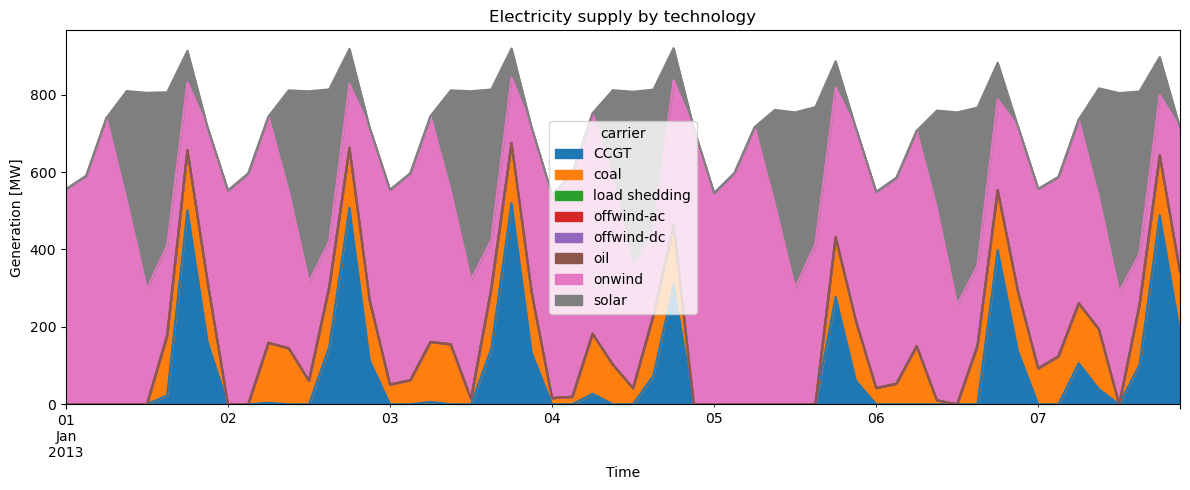

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Generator dispatch by carrier
supply_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()

print(supply_by_carrier.head())

supply_by_carrier.plot.area(figsize=(12, 5))
plt.ylabel("Generation [MW]")
plt.xlabel("Time")
plt.title("Electricity supply by technology")
plt.tight_layout()
plt.show()

Annual demand [GWh]:
41.18778069087655

Annual generation by carrier [GWh]:
carrier
onwind           1.858967e+01
solar            1.051284e+01
coal             6.212073e+00
CCGT             5.873195e+00
offwind-ac       5.947168e-12
offwind-dc       1.240597e-12
oil              7.883001e-13
load shedding    1.907305e-15
dtype: float64

Installed generator capacity by carrier [MW]:
carrier
solar            1.473948e+03
load shedding    1.104051e+03
onwind           1.027504e+03
CCGT             6.460000e+02
oil              6.089600e+02
coal             1.550000e+02
offwind-ac       3.871512e-10
offwind-dc       1.002819e-10
Name: p_nom_opt, dtype: float64

Installed link capacity by carrier [MW]:
carrier
battery discharger    4.119757e-09
battery charger       3.954967e-09
H2 fuel cell          1.990161e-09
H2 electrolysis       3.796826e-10
Name: p_nom_opt, dtype: float64

Installed store energy capacity by carrier [MWh]:
carrier
H2         3.007209e-07
battery    5.180639e-09
Name:

/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_1494/1897456331.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  supply_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()


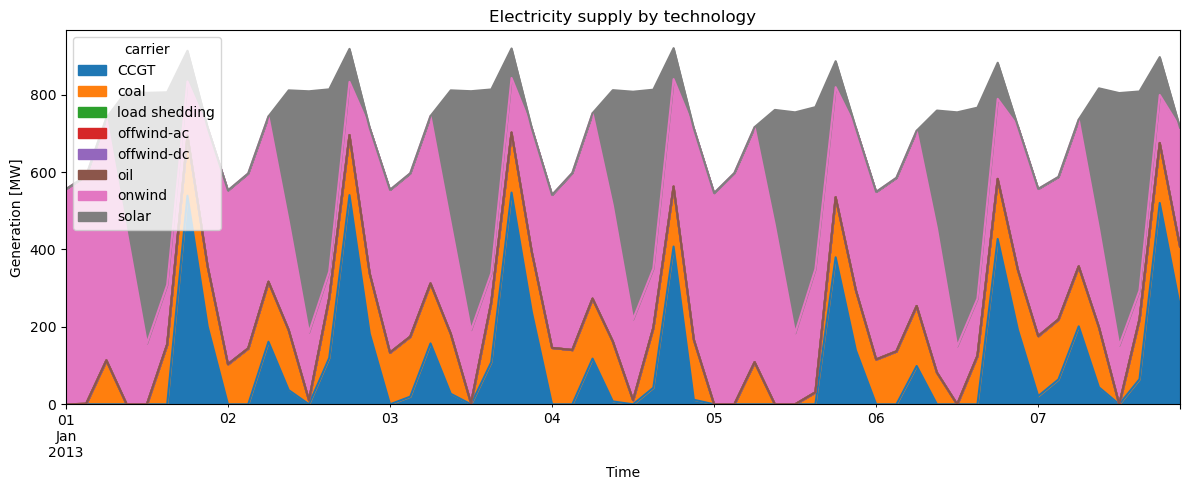

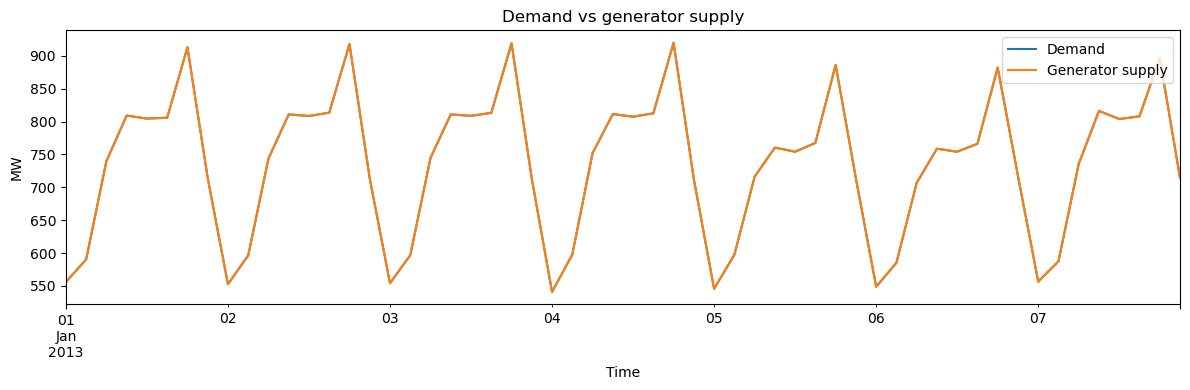

: 

In [ ]:
import pypsa
import matplotlib.pyplot as plt


# Demand
demand = n.loads_t.p_set.sum(axis=1)

# Generator supply by carrier
supply_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()

print("Annual demand [GWh]:")
print(demand.sum() / 1_000)

print("\nAnnual generation by carrier [GWh]:")
print((supply_by_carrier.sum() / 1_000).sort_values(ascending=False))

print("\nInstalled generator capacity by carrier [MW]:")
print(n.generators.p_nom_opt.groupby(n.generators.carrier).sum().sort_values(ascending=False))

if not n.links.empty:
    print("\nInstalled link capacity by carrier [MW]:")
    print(n.links.p_nom_opt.groupby(n.links.carrier).sum().sort_values(ascending=False))

if not n.stores.empty:
    print("\nInstalled store energy capacity by carrier [MWh]:")
    print(n.stores.e_nom_opt.groupby(n.stores.carrier).sum().sort_values(ascending=False))

# Plot supply
supply_by_carrier.plot.area(figsize=(12, 5))
plt.ylabel("Generation [MW]")
plt.xlabel("Time")
plt.title("Electricity supply by technology")
plt.tight_layout()
plt.show()

# Plot demand vs generation
plt.figure(figsize=(12, 4))
demand.plot(label="Demand")
supply_by_carrier.sum(axis=1).plot(label="Generator supply")
plt.ylabel("MW")
plt.xlabel("Time")
plt.title("Demand vs generator supply")
plt.legend()
plt.tight_layout()
plt.show()

INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, loads


Network loaded:
networks/elec_s.nc

Number of generators: 86
Number of buses: 24

Existing/non-extendable generators: 14

Using bus coordinates.

Existing generators with coordinates: 14

Available columns:
['carrier', 'bus', 'p_nom', 'p_nom_opt', 'p_nom_extendable', 'marginal_cost', 'capital_cost', 'efficiency', 'build_year', 'lifetime', 'x_plot', 'y_plot']

Existing capacity by carrier [MW]:
carrier
CCGT    646.00
oil     608.96
coal    155.00
Name: p_nom, dtype: float64

Exported table to: existing_power_plants_mapped.xlsx



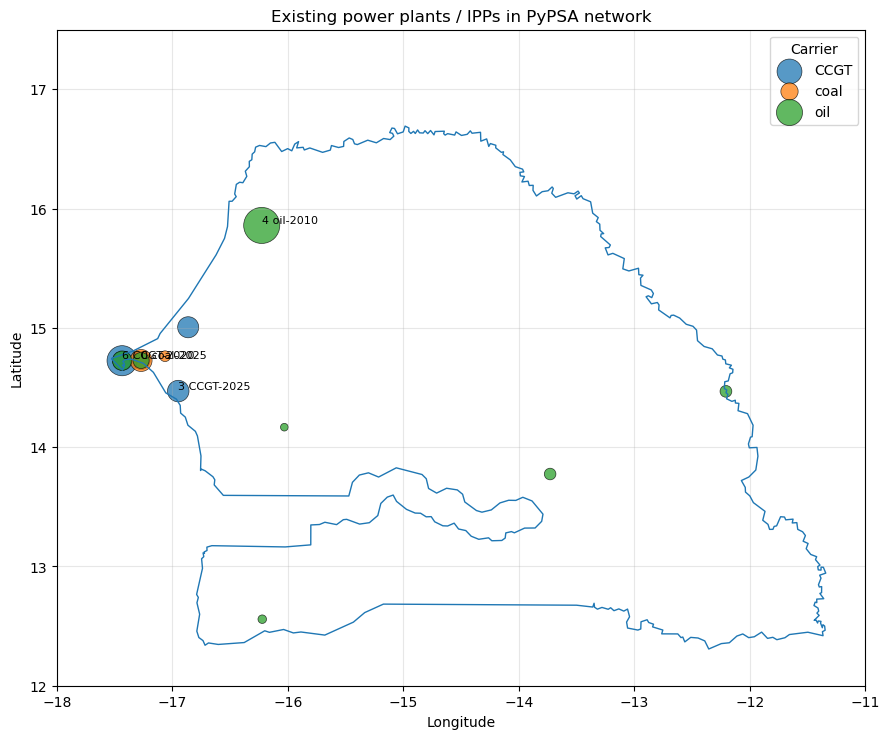

Saved map to: existing_power_plants_map.png


In [40]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

# Optional, but useful for geographic maps
try:
    import geopandas as gpd
except ImportError:
    gpd = None


# ============================================================
# 1. SETTINGS
# ============================================================

NETWORK_PATH = "networks/elec_s.nc"
# Other examples:
# NETWORK_PATH = "networks/elec_s_4.nc"
# NETWORK_PATH = "results/SN/networks/elec_s_4_ec_lcopt_Co2L-3H.nc"

COUNTRY_SHAPE_PATH = "resources/shapes/country_shapes.geojson"

OUTPUT_EXCEL = "existing_power_plants_mapped.xlsx"
OUTPUT_FIGURE = "existing_power_plants_map.png"


# ============================================================
# 2. LOAD NETWORK
# ============================================================

n = pypsa.Network(NETWORK_PATH)

print("Network loaded:")
print(NETWORK_PATH)
print()

print("Number of generators:", len(n.generators))
print("Number of buses:", len(n.buses))
print()


# ============================================================
# 3. SELECT EXISTING POWER PLANTS
# ============================================================

# Existing plants are usually non-extendable.
# New-build candidate generators are usually extendable.
if "p_nom_extendable" in n.generators.columns:
    existing = n.generators[n.generators["p_nom_extendable"] == False].copy()
else:
    existing = n.generators.copy()

print("Existing/non-extendable generators:", len(existing))
print()

if existing.empty:
    raise ValueError(
        "No existing/non-extendable generators found. "
        "Try plotting all generators, or check whether your network has existing plants."
    )


# ============================================================
# 4. ADD COORDINATES
# ============================================================

# Some PyPSA-Earth generator tables may have x/y directly.
# If not, use the coordinates of the bus to which each generator is connected.

if {"x", "y"}.issubset(existing.columns):
    existing["x_plot"] = existing["x"]
    existing["y_plot"] = existing["y"]
    coord_source = "generator coordinates"
else:
    if "bus" not in existing.columns:
        raise ValueError("No 'bus' column found in n.generators.")

    missing_buses = set(existing["bus"]) - set(n.buses.index)
    if missing_buses:
        print("Warning: some generator buses are missing from n.buses:")
        print(missing_buses)

    existing["x_plot"] = existing["bus"].map(n.buses["x"])
    existing["y_plot"] = existing["bus"].map(n.buses["y"])
    coord_source = "bus coordinates"

print(f"Using {coord_source}.")
print()

# Remove generators without valid coordinates
existing = existing.dropna(subset=["x_plot", "y_plot"]).copy()

print("Existing generators with coordinates:", len(existing))
print()


# ============================================================
# 5. PREPARE USEFUL COLUMNS
# ============================================================

useful_cols = [
    "carrier",
    "bus",
    "p_nom",
    "p_nom_opt",
    "p_nom_extendable",
    "marginal_cost",
    "capital_cost",
    "efficiency",
    "build_year",
    "lifetime",
    "x_plot",
    "y_plot",
]

available_cols = [c for c in useful_cols if c in existing.columns]

print("Available columns:")
print(available_cols)
print()

print("Existing capacity by carrier [MW]:")
if "carrier" in existing.columns and "p_nom" in existing.columns:
    print(existing.groupby("carrier")["p_nom"].sum().sort_values(ascending=False))
print()


# ============================================================
# 6. EXPORT TABLE
# ============================================================

existing_export = existing[available_cols].copy()
existing_export.index.name = "generator_name"
existing_export.to_excel(OUTPUT_EXCEL)

print(f"Exported table to: {OUTPUT_EXCEL}")
print()


# ============================================================
# 7. PLOT MAP
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Plot Senegal shape if geopandas is available and the file exists.
if gpd is not None:
    try:
        shapes = gpd.read_file(COUNTRY_SHAPE_PATH)

        # Try to filter Senegal if country column exists
        possible_country_cols = ["name", "Name", "country", "Country", "CNTR_ID", "iso2", "ISO_A2"]
        filtered = shapes.copy()

        for col in possible_country_cols:
            if col in shapes.columns:
                mask = (
                    shapes[col].astype(str).str.contains("Senegal", case=False, na=False)
                    | shapes[col].astype(str).str.contains("SN", case=False, na=False)
                )
                if mask.any():
                    filtered = shapes[mask].copy()
                    break

        filtered.boundary.plot(ax=ax, linewidth=1)
    except Exception as e:
        print("Could not plot country shape. Continuing with points only.")
        print("Reason:", e)
else:
    print("geopandas is not installed. Continuing with points only.")

# Marker size based on installed capacity
if "p_nom" in existing.columns:
    capacities = existing["p_nom"].fillna(0)

    # Prevent invisible dots
    marker_sizes = capacities.clip(lower=5) * 2
else:
    marker_sizes = 40

# Plot by carrier
if "carrier" in existing.columns:
    for carrier, group in existing.groupby("carrier"):
        if "p_nom" in group.columns:
            sizes = group["p_nom"].fillna(0).clip(lower=5) * 2
        else:
            sizes = 40

        ax.scatter(
            group["x_plot"],
            group["y_plot"],
            s=sizes,
            alpha=0.75,
            label=carrier,
            edgecolors="black",
            linewidths=0.5,
        )
else:
    ax.scatter(
        existing["x_plot"],
        existing["y_plot"],
        s=marker_sizes,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.5,
    )

# Add labels for larger plants
if "p_nom" in existing.columns:
    label_threshold_mw = existing["p_nom"].quantile(0.70)
else:
    label_threshold_mw = None

for name, row in existing.iterrows():
    label_this = True

    if "p_nom" in existing.columns and label_threshold_mw is not None:
        label_this = row["p_nom"] >= label_threshold_mw

    if label_this:
        ax.text(
            row["x_plot"],
            row["y_plot"],
            str(name),
            fontsize=8,
            ha="left",
            va="bottom",
        )

ax.set_title("Existing power plants / IPPs in PyPSA network")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

if "carrier" in existing.columns:
    ax.legend(title="Carrier", loc="best")

# Zoom roughly to Senegal if coordinates are lon/lat
ax.set_xlim(-18.0, -11.0)
ax.set_ylim(12.0, 17.5)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, dpi=300)
plt.show()

print(f"Saved map to: {OUTPUT_FIGURE}")


# ============================================================
# 8. OPTIONAL: PLOT ALL GENERATORS INCLUDING NEW CANDIDATES
# ============================================================

plot_all_generators = False

if plot_all_generators:
    gens = n.generators.copy()

    if {"x", "y"}.issubset(gens.columns):
        gens["x_plot"] = gens["x"]
        gens["y_plot"] = gens["y"]
    else:
        gens["x_plot"] = gens["bus"].map(n.buses["x"])
        gens["y_plot"] = gens["bus"].map(n.buses["y"])

    gens = gens.dropna(subset=["x_plot", "y_plot"])

    fig, ax = plt.subplots(figsize=(9, 9))

    if gpd is not None:
        try:
            shapes = gpd.read_file(COUNTRY_SHAPE_PATH)
            shapes.boundary.plot(ax=ax, linewidth=1)
        except Exception:
            pass

    for carrier, group in gens.groupby("carrier"):
        if "p_nom_opt" in group.columns:
            sizes = group["p_nom_opt"].fillna(group.get("p_nom", 0)).clip(lower=5) * 2
        elif "p_nom" in group.columns:
            sizes = group["p_nom"].fillna(0).clip(lower=5) * 2
        else:
            sizes = 40

        ax.scatter(
            group["x_plot"],
            group["y_plot"],
            s=sizes,
            alpha=0.65,
            label=carrier,
            edgecolors="black",
            linewidths=0.5,
        )

    ax.set_title("All generators in PyPSA network")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Carrier", loc="best")
    ax.set_xlim(-18.0, -11.0)
    ax.set_ylim(12.0, 17.5)

    plt.tight_layout()
    plt.savefig("all_generators_map.png", dpi=300)
    plt.show()

In [41]:
import pypsa
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

NETWORK_PATH = "networks/elec_s.nc"
# Try also:
# NETWORK_PATH = "networks/elec_s_4.nc"
# NETWORK_PATH = "results/SN/networks/elec_s_4_ec_lcopt_Co2L-3H.nc"

# ============================================================
# LOAD NETWORK
# ============================================================

n = pypsa.Network(NETWORK_PATH)

print("=" * 80)
print("NETWORK SUMMARY")
print("=" * 80)
print("Network:", NETWORK_PATH)
print("Buses:", len(n.buses))
print("Generators:", len(n.generators))
print("Links:", len(n.links))
print("Stores:", len(n.stores))
print("Storage units:", len(n.storage_units))
print()

print("=" * 80)
print("GENERATOR CARRIERS")
print("=" * 80)

if len(n.generators) == 0:
    print("No generators found in this network.")
else:
    print(n.generators["carrier"].value_counts(dropna=False))
print()

print("=" * 80)
print("GENERATOR CAPACITY BY CARRIER")
print("=" * 80)

if len(n.generators) > 0:
    if "p_nom" in n.generators.columns:
        print("Existing / nominal p_nom capacity [MW]:")
        print(n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False))
        print()

    if "p_nom_opt" in n.generators.columns:
        print("Optimized p_nom_opt capacity [MW]:")
        print(n.generators.groupby("carrier")["p_nom_opt"].sum().sort_values(ascending=False))
        print()

    if "p_nom_max" in n.generators.columns:
        print("Maximum potential p_nom_max capacity [MW]:")
        print(n.generators.groupby("carrier")["p_nom_max"].sum().sort_values(ascending=False))
        print()

print("=" * 80)
print("SOLAR AND WIND GENERATORS")
print("=" * 80)

renewable_carriers = ["solar", "onwind", "offwind-ac", "offwind-dc", "offwind"]

vre = n.generators[n.generators["carrier"].isin(renewable_carriers)].copy()

print("Number of solar/wind generators:", len(vre))
print()

if len(vre) == 0:
    print("No solar/wind generators found.")
    print("Possible reasons:")
    print("- You are using the wrong network stage.")
    print("- Renewable generators were not added yet.")
    print("- The carriers have different names.")
    print("- Renewable potentials failed during build.")
else:
    cols = [
        "carrier",
        "bus",
        "p_nom",
        "p_nom_min",
        "p_nom_max",
        "p_nom_extendable",
        "p_nom_opt",
        "capital_cost",
        "marginal_cost",
        "build_year",
        "lifetime",
    ]
    cols = [c for c in cols if c in vre.columns]

    display(vre[cols].head(100))

    print()
    print("Solar/wind by carrier:")
    print(vre.groupby("carrier").size())

    if "p_nom" in vre.columns:
        print()
        print("Solar/wind p_nom by carrier [MW]:")
        print(vre.groupby("carrier")["p_nom"].sum().sort_values(ascending=False))

    if "p_nom_max" in vre.columns:
        print()
        print("Solar/wind p_nom_max by carrier [MW]:")
        print(vre.groupby("carrier")["p_nom_max"].sum().sort_values(ascending=False))

    if "p_nom_opt" in vre.columns:
        print()
        print("Solar/wind p_nom_opt by carrier [MW]:")
        print(vre.groupby("carrier")["p_nom_opt"].sum().sort_values(ascending=False))

INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, loads


NETWORK SUMMARY
Network: networks/elec_s.nc
Buses: 24
Generators: 86
Links: 0
Stores: 0
Storage units: 0

GENERATOR CARRIERS
carrier
onwind        24
solar         24
offwind-dc    12
offwind-ac    12
oil            7
CCGT           5
coal           2
Name: count, dtype: int64

GENERATOR CAPACITY BY CARRIER
Existing / nominal p_nom capacity [MW]:
carrier
CCGT          646.00
oil           608.96
solar         400.30
onwind        208.00
coal          155.00
offwind-ac      0.00
offwind-dc      0.00
Name: p_nom, dtype: float64

Optimized p_nom_opt capacity [MW]:
carrier
CCGT          0.0
coal          0.0
offwind-ac    0.0
offwind-dc    0.0
oil           0.0
onwind        0.0
solar         0.0
Name: p_nom_opt, dtype: float64

Maximum potential p_nom_max capacity [MW]:
carrier
solar         520271.388021
onwind        368793.776295
offwind-dc     18531.404548
offwind-ac     12300.352781
CCGT             646.000000
oil              608.960000
coal             155.000000
Name: p_nom_max, d

,carrier,bus,p_nom,p_nom_min,p_nom_max,p_nom_extendable,p_nom_opt,capital_cost,marginal_cost,build_year,lifetime
Generator,,,,,,,,,,,
0 offwind-dc,offwind-dc,1,0.0,0.0,12.733554,True,0.0,219459.514597,0.015,0,30.0
2 offwind-dc,offwind-dc,2,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,0,30.0
3 offwind-dc,offwind-dc,3,0.0,0.0,4298.546176,True,0.0,226190.803464,0.015,0,30.0
4 offwind-dc,offwind-dc,5,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,0,30.0
6 offwind-dc,offwind-dc,6,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,0,30.0
...,...,...,...,...,...,...,...,...,...,...,...
23 solar,solar,23,0.0,0.0,1943.865502,True,0.0,39296.472708,0.010,0,40.0
24 solar,solar,24,0.0,0.0,4568.858733,True,0.0,39296.472708,0.010,0,40.0
25 solar,solar,25,0.0,0.0,49075.600890,True,0.0,39296.472708,0.010,0,40.0



Solar/wind by carrier:
carrier
offwind-ac    12
offwind-dc    12
onwind        24
solar         24
dtype: int64

Solar/wind p_nom by carrier [MW]:
carrier
solar         400.3
onwind        208.0
offwind-ac      0.0
offwind-dc      0.0
Name: p_nom, dtype: float64

Solar/wind p_nom_max by carrier [MW]:
carrier
solar         520271.388021
onwind        368793.776295
offwind-dc     18531.404548
offwind-ac     12300.352781
Name: p_nom_max, dtype: float64

Solar/wind p_nom_opt by carrier [MW]:
carrier
offwind-ac    0.0
offwind-dc    0.0
onwind        0.0
solar         0.0
Name: p_nom_opt, dtype: float64


INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, loads


Loaded network: networks/elec_s.nc
Number of buses: 24
Number of generators: 86

Number of solar/wind generators: 72

Solar/wind generators with coordinates: 72

Solar/wind table preview:


,carrier,bus,p_nom,p_nom_min,p_nom_max,p_nom_extendable,p_nom_opt,capital_cost,marginal_cost,x_plot,y_plot
Generator,,,,,,,,,,,
0 offwind-dc,offwind-dc,1,0.0,0.0,12.733554,True,0.0,219459.514597,0.015,-17.2719,14.7269
2 offwind-dc,offwind-dc,2,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,-17.3490,14.7563
3 offwind-dc,offwind-dc,3,0.0,0.0,4298.546176,True,0.0,226190.803464,0.015,-16.9502,14.4705
4 offwind-dc,offwind-dc,5,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,-16.2273,15.8592
6 offwind-dc,offwind-dc,6,0.0,0.0,0.000000,True,0.0,210878.845360,0.015,-17.4366,14.7251
...,...,...,...,...,...,...,...,...,...,...,...
23 solar,solar,23,0.0,0.0,1943.865502,True,0.0,39296.472708,0.010,-17.0645,14.7627
24 solar,solar,24,0.0,0.0,4568.858733,True,0.0,39296.472708,0.010,-16.2227,12.5578
25 solar,solar,25,0.0,0.0,49075.600890,True,0.0,39296.472708,0.010,-15.7481,14.0892



Solar/wind count by carrier:
carrier
offwind-ac    12
offwind-dc    12
onwind        24
solar         24
dtype: int64

p_nom by carrier [MW]:
carrier
solar         400.3
onwind        208.0
offwind-ac      0.0
offwind-dc      0.0
Name: p_nom, dtype: float64

p_nom_max by carrier [MW]:
carrier
solar         520271.388021
onwind        368793.776295
offwind-dc     18531.404548
offwind-ac     12300.352781
Name: p_nom_max, dtype: float64

p_nom_opt by carrier [MW]:
carrier
offwind-ac    0.0
offwind-dc    0.0
onwind        0.0
solar         0.0
Name: p_nom_opt, dtype: float64

Exported solar/wind table to: solar_wind_generators_table.xlsx

Using marker size based on: p_nom_max



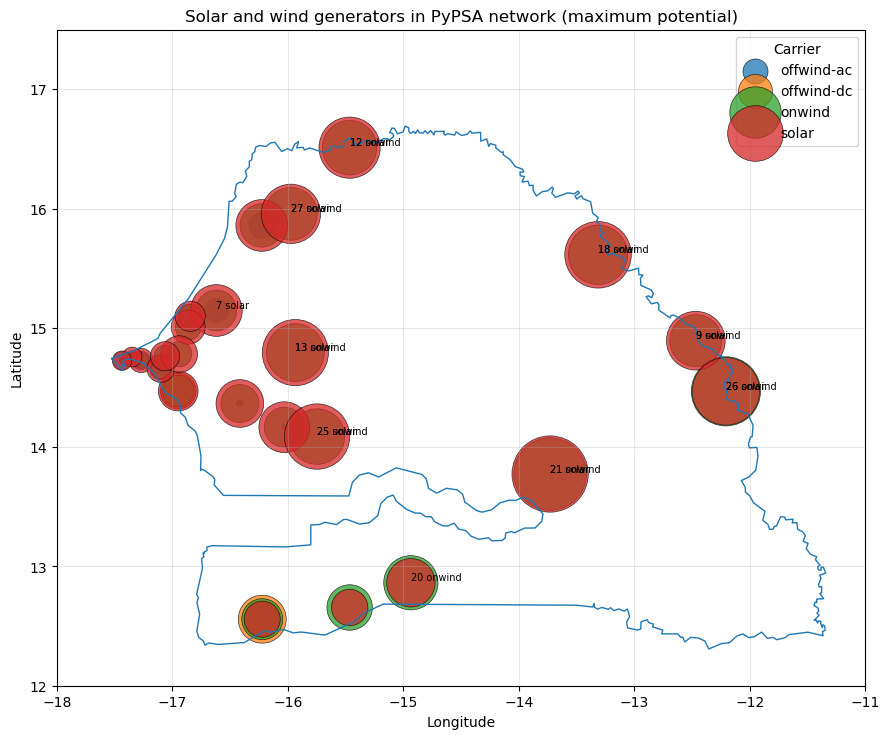

Saved figure to: solar_wind_generators_map.png


In [42]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
except ImportError:
    gpd = None


# ============================================================
# SETTINGS
# ============================================================

NETWORK_PATH = "networks/elec_s.nc"
# Try:
# NETWORK_PATH = "networks/elec_s_4.nc"
# NETWORK_PATH = "results/SN/networks/elec_s_4_ec_lcopt_Co2L-3H.nc"

COUNTRY_SHAPE_PATH = "resources/shapes/country_shapes.geojson"

OUTPUT_FIGURE = "solar_wind_generators_map.png"
OUTPUT_EXCEL = "solar_wind_generators_table.xlsx"

RENEWABLE_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc", "offwind"]


# ============================================================
# LOAD NETWORK
# ============================================================

n = pypsa.Network(NETWORK_PATH)

print("Loaded network:", NETWORK_PATH)
print("Number of buses:", len(n.buses))
print("Number of generators:", len(n.generators))
print()


# ============================================================
# FILTER SOLAR AND WIND
# ============================================================

vre = n.generators[n.generators["carrier"].isin(RENEWABLE_CARRIERS)].copy()

print("Number of solar/wind generators:", len(vre))
print()

if vre.empty:
    print("No solar/wind generators found.")
    print("Available carriers are:")
    print(n.generators["carrier"].value_counts())
    raise SystemExit


# ============================================================
# ADD COORDINATES
# ============================================================

# Usually generators do not have their own coordinates.
# They are attached to buses, so we use bus coordinates.
vre["x_plot"] = vre["bus"].map(n.buses["x"])
vre["y_plot"] = vre["bus"].map(n.buses["y"])

# Remove rows without coordinates
vre = vre.dropna(subset=["x_plot", "y_plot"]).copy()

print("Solar/wind generators with coordinates:", len(vre))
print()

if vre.empty:
    raise ValueError("Solar/wind generators exist, but no valid bus coordinates were found.")


# ============================================================
# PRINT USEFUL SUMMARY
# ============================================================

cols = [
    "carrier",
    "bus",
    "p_nom",
    "p_nom_min",
    "p_nom_max",
    "p_nom_extendable",
    "p_nom_opt",
    "capital_cost",
    "marginal_cost",
    "x_plot",
    "y_plot",
]

cols = [c for c in cols if c in vre.columns]

print("Solar/wind table preview:")
display(vre[cols].head(100))
print()

print("Solar/wind count by carrier:")
print(vre.groupby("carrier").size())
print()

if "p_nom" in vre.columns:
    print("p_nom by carrier [MW]:")
    print(vre.groupby("carrier")["p_nom"].sum().sort_values(ascending=False))
    print()

if "p_nom_max" in vre.columns:
    print("p_nom_max by carrier [MW]:")
    print(vre.groupby("carrier")["p_nom_max"].sum().sort_values(ascending=False))
    print()

if "p_nom_opt" in vre.columns:
    print("p_nom_opt by carrier [MW]:")
    print(vre.groupby("carrier")["p_nom_opt"].sum().sort_values(ascending=False))
    print()


# ============================================================
# EXPORT TABLE
# ============================================================

vre[cols].to_excel(OUTPUT_EXCEL)
print("Exported solar/wind table to:", OUTPUT_EXCEL)
print()


# ============================================================
# CHOOSE MARKER SIZE
# ============================================================

# For solved networks, p_nom_opt is the most useful.
# For unsolved networks, p_nom_max shows potential.
# p_nom may be zero for extendable renewables.

if "p_nom_opt" in vre.columns and vre["p_nom_opt"].fillna(0).sum() > 0:
    size_col = "p_nom_opt"
    title_capacity = "optimized capacity"
elif "p_nom_max" in vre.columns and vre["p_nom_max"].replace(float("inf"), 0).fillna(0).sum() > 0:
    size_col = "p_nom_max"
    title_capacity = "maximum potential"
elif "p_nom" in vre.columns and vre["p_nom"].fillna(0).sum() > 0:
    size_col = "p_nom"
    title_capacity = "nominal capacity"
else:
    size_col = None
    title_capacity = "locations"

print("Using marker size based on:", size_col)
print()


# ============================================================
# PLOT MAP
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Plot country shape if available
if gpd is not None:
    try:
        shapes = gpd.read_file(COUNTRY_SHAPE_PATH)

        # Try to filter Senegal
        filtered = shapes.copy()
        for col in shapes.columns:
            if shapes[col].dtype == "object":
                mask = (
                    shapes[col].astype(str).str.contains("Senegal", case=False, na=False)
                    | shapes[col].astype(str).str.fullmatch("SN", case=False, na=False)
                )
                if mask.any():
                    filtered = shapes[mask].copy()
                    break

        filtered.boundary.plot(ax=ax, linewidth=1)
    except Exception as e:
        print("Could not plot country shape.")
        print("Reason:", e)

# Plot solar/wind
for carrier, group in vre.groupby("carrier"):
    if size_col is not None:
        raw_sizes = group[size_col].replace(float("inf"), 0).fillna(0)

        # If some potentials are huge, use sqrt scaling
        sizes = raw_sizes.clip(lower=1) ** 0.5 * 10
    else:
        sizes = 60

    ax.scatter(
        group["x_plot"],
        group["y_plot"],
        s=sizes,
        alpha=0.75,
        label=carrier,
        edgecolors="black",
        linewidths=0.5,
    )

# Add labels only for large points
if size_col is not None:
    values = vre[size_col].replace(float("inf"), 0).fillna(0)
    threshold = values.quantile(0.75)

    for name, row in vre.iterrows():
        if row[size_col] >= threshold and row[size_col] > 0:
            ax.text(
                row["x_plot"],
                row["y_plot"],
                str(name),
                fontsize=7,
                ha="left",
                va="bottom",
            )

ax.set_title(f"Solar and wind generators in PyPSA network ({title_capacity})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend(title="Carrier")

# Senegal approximate bounds
ax.set_xlim(-18.0, -11.0)
ax.set_ylim(12.0, 17.5)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, dpi=300)
plt.show()

print("Saved figure to:", OUTPUT_FIGURE)

Loaded: resources/powerplants.csv
Columns:
['Unnamed: 0', 'Name', 'Fueltype', 'Technology', 'Set', 'Country', 'Capacity', 'Efficiency', 'Duration', 'Volume_Mm3', 'DamHeight_m', 'StorageCapacity_MWh', 'DateIn', 'DateRetrofit', 'DateOut', 'lat', 'lon', 'EIC', 'projectID', 'bus', 'region_id']

Senegal rows: 34

Senegal solar/wind rows: 17


,Unnamed: 0,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,Duration,Volume_Mm3,...,StorageCapacity_MWh,DateIn,DateRetrofit,DateOut,lat,lon,EIC,projectID,bus,region_id
0,0,Bokhol Solar Farm,Solar,PV,PP,SN,20.0,NaN,NaN,NaN,...,NaN,2016.00,2016.00,2041.00,16.51720,-15.46920,{nan},"{'GEM': {'G100000800081'}, 'GPD': {'WKS0067471'}}",12,SN.10_1
1,1,Kahone Solaire Sa Solar Farm,Solar,PV,PP,SN,60.0,NaN,NaN,NaN,...,NaN,2017.00,2017.00,2042.00,14.17350,-16.02600,"{nan, nan}","{'GEM': {'G100000800192', 'G100000800191'}, 'G...",19,SN.5_1
2,2,Ten Merina Solar Farm,Solar,PV,PP,SN,30.0,NaN,NaN,NaN,...,NaN,2018.00,2018.00,2043.00,15.13010,-16.67600,{nan},"{'GEM': {'G100000800396'}, 'GPD': {'WKS0067472'}}",7,SN.13_1
7,7,Merina Dakhar,Solar,NaN,PP,SN,34.4,NaN,NaN,NaN,...,NaN,2019.25,2019.25,2044.25,15.15500,-16.59300,{nan},{'GPD': {'WKS0069752'}},7,SN.13_1
13,13,Dakar Region Solar,Solar,PV,PP,SN,7.8,NaN,NaN,NaN,...,NaN,2023.00,2023.00,2048.00,14.68600,-17.19720,{nan},{'GEM': {'G100001023921'}},0,SN.1_1
14,14,Dakar Region Solar,Solar,PV,PP,SN,3.6,NaN,NaN,NaN,...,NaN,2021.00,2021.00,2046.00,14.73775,-17.19845,"{nan, nan}","{'GEM': {'G100001023919', 'G100001074654'}}",0,SN.1_1
15,15,Diass Solar Farm,Solar,PV,PP,SN,23.0,NaN,NaN,NaN,...,NaN,2022.00,2022.00,2047.00,14.65200,-17.10300,{nan},{'GEM': {'G100000814195'}},8,SN.13_1
17,17,Kael Solar Farm,Solar,PV,PP,SN,35.0,NaN,NaN,NaN,...,NaN,2021.00,2021.00,2046.00,14.77280,-15.92220,{nan},{'GEM': {'G100000800190'}},13,SN.2_1
21,21,Leona Wind Farm,Wind,Onshore,PP,SN,50.0,NaN,NaN,NaN,...,NaN,2019.00,2019.00,2044.00,15.83710,-16.33990,{nan},{'GEM': {'G100000900099'}},4,SN.10_1
23,23,Malicounda Solar Farm,Solar,PV,PP,SN,22.0,NaN,NaN,NaN,...,NaN,2016.00,2016.00,2041.00,14.47360,-16.93540,{nan},{'GEM': {'G100000800248'}},3,SN.13_1


Renewable plants with coordinates: 17

Exported table to: raw_senegal_renewable_powerplants.xlsx


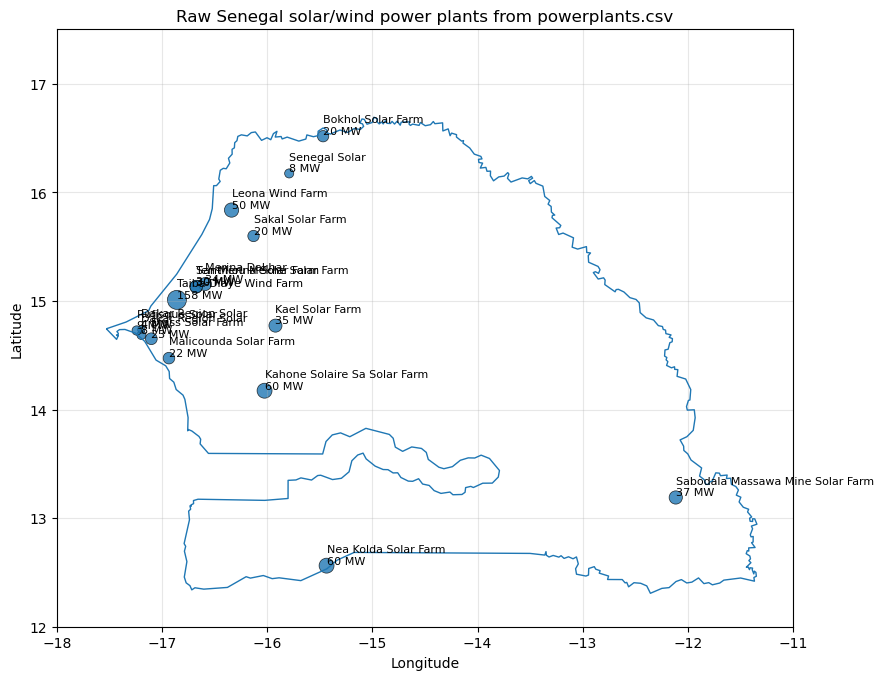

Saved figure to: raw_senegal_renewable_powerplants_map.png


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    import geopandas as gpd
except ImportError:
    gpd = None


# ============================================================
# SETTINGS
# ============================================================

POWERPLANT_PATH = "resources/powerplants.csv"
COUNTRY_SHAPE_PATH = "resources/shapes/country_shapes.geojson"

OUTPUT_FIGURE = "raw_senegal_renewable_powerplants_map.png"
OUTPUT_EXCEL = "raw_senegal_renewable_powerplants.xlsx"


# ============================================================
# LOAD POWERPLANT FILE
# ============================================================

pp = pd.read_csv(POWERPLANT_PATH)

print("Loaded:", POWERPLANT_PATH)
print("Columns:")
print(pp.columns.tolist())
print()


# ============================================================
# FIND SENEGAL ROWS
# ============================================================

country_col = None

for c in pp.columns:
    if c.lower() in ["country", "country_name", "countryname", "country code", "country_code", "iso2", "iso3"]:
        country_col = c
        break

if country_col is not None:
    pp_sn = pp[
        pp[country_col].astype(str).str.contains("Senegal|SN", case=False, na=False)
    ].copy()
else:
    # fallback: text search across all columns
    pp_sn = pp[
        pp.astype(str).apply(
            lambda row: row.str.contains("Senegal|SN", case=False, na=False).any(),
            axis=1,
        )
    ].copy()

print("Senegal rows:", len(pp_sn))
print()


# ============================================================
# FILTER SOLAR/WIND
# ============================================================

renewable_keywords = "solar|wind|pv|photovoltaic|onshore|offshore"

pp_re = pp_sn[
    pp_sn.astype(str).apply(
        lambda row: row.str.contains(renewable_keywords, case=False, na=False).any(),
        axis=1,
    )
].copy()

print("Senegal solar/wind rows:", len(pp_re))
display(pp_re)

if pp_re.empty:
    raise SystemExit("No Senegal solar/wind plants found in raw powerplant file.")


# ============================================================
# DETECT COORDINATE COLUMNS
# ============================================================

possible_lon_cols = ["lon", "Lon", "longitude", "Longitude", "x", "X"]
possible_lat_cols = ["lat", "Lat", "latitude", "Latitude", "y", "Y"]

lon_col = next((c for c in possible_lon_cols if c in pp_re.columns), None)
lat_col = next((c for c in possible_lat_cols if c in pp_re.columns), None)

if lon_col is None or lat_col is None:
    print("Could not find coordinate columns.")
    print("Available columns:", pp_re.columns.tolist())
    raise SystemExit

pp_re[lon_col] = pd.to_numeric(pp_re[lon_col], errors="coerce")
pp_re[lat_col] = pd.to_numeric(pp_re[lat_col], errors="coerce")
pp_re = pp_re.dropna(subset=[lon_col, lat_col]).copy()

print("Renewable plants with coordinates:", len(pp_re))
print()


# ============================================================
# DETECT CAPACITY AND NAME COLUMNS
# ============================================================

possible_capacity_cols = ["Capacity", "Capacity_MW", "capacity", "p_nom", "P_nom"]
possible_name_cols = ["Name", "name", "Plant", "plant", "Project", "project"]

cap_col = next((c for c in possible_capacity_cols if c in pp_re.columns), None)
name_col = next((c for c in possible_name_cols if c in pp_re.columns), None)

if cap_col is not None:
    pp_re[cap_col] = pd.to_numeric(pp_re[cap_col], errors="coerce")
    sizes = pp_re[cap_col].fillna(1).clip(lower=1) ** 0.5 * 15
else:
    sizes = 80

pp_re.to_excel(OUTPUT_EXCEL, index=False)
print("Exported table to:", OUTPUT_EXCEL)


# ============================================================
# PLOT MAP
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

if gpd is not None:
    try:
        shapes = gpd.read_file(COUNTRY_SHAPE_PATH)

        filtered = shapes.copy()
        for col in shapes.columns:
            if shapes[col].dtype == "object":
                mask = (
                    shapes[col].astype(str).str.contains("Senegal", case=False, na=False)
                    | shapes[col].astype(str).str.fullmatch("SN", case=False, na=False)
                )
                if mask.any():
                    filtered = shapes[mask].copy()
                    break

        filtered.boundary.plot(ax=ax, linewidth=1)
    except Exception as e:
        print("Could not plot country shape:", e)

ax.scatter(
    pp_re[lon_col],
    pp_re[lat_col],
    s=sizes,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.5,
)

if name_col is not None:
    for _, row in pp_re.iterrows():
        label = str(row[name_col])

        if cap_col is not None and pd.notna(row[cap_col]):
            label += f"\n{row[cap_col]:.0f} MW"

        ax.text(
            row[lon_col],
            row[lat_col],
            label,
            fontsize=8,
            ha="left",
            va="bottom",
        )

ax.set_title("Raw Senegal solar/wind power plants from powerplants.csv")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

ax.set_xlim(-18.0, -11.0)
ax.set_ylim(12.0, 17.5)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, dpi=300)
plt.show()

print("Saved figure to:", OUTPUT_FIGURE)

NameError: name 'bus_sizes' is not defined

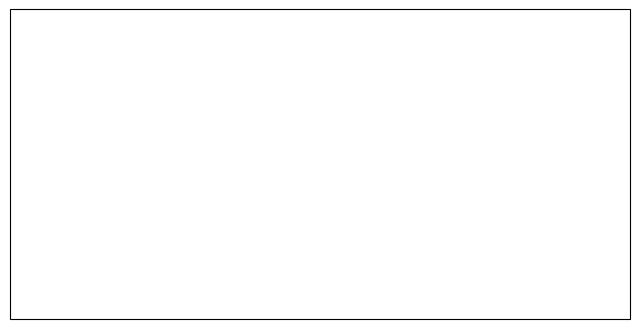

In [4]:
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

n.plot(
    ax=ax,
    bus_sizes=bus_sizes / 3e4,
    color_geomap=True,
    title="Senegal Network - Generator Capacity by Type",
)

plt.tight_layout()
plt.show()

INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores


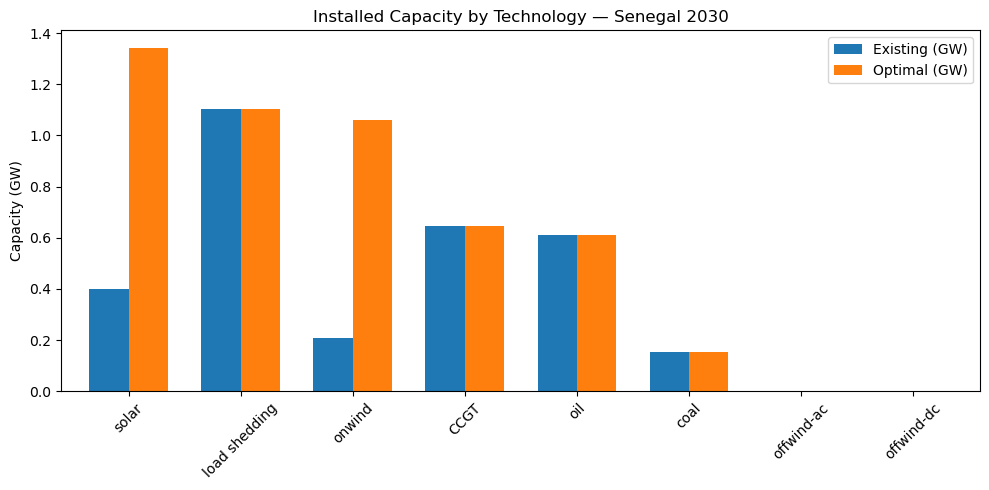

               Existing (GW)  Optimal (GW)
carrier                                   
solar               0.400300  1.343322e+00
load shedding       1.104051  1.104051e+00
onwind              0.208000  1.059783e+00
CCGT                0.646000  6.460000e-01
oil                 0.608960  6.089600e-01
coal                0.155000  1.550000e-01
offwind-ac          0.000000  3.152919e-14
offwind-dc          0.000000  1.739261e-14


In [49]:
import pypsa
import matplotlib.pyplot as plt
import pandas as pd

n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")

# Existing capacity (before optimization)
p_nom = n.generators.groupby("carrier")["p_nom"].sum() / 1e3  # GW

# Optimal capacity (after optimization)
p_nom_opt = n.generators.groupby("carrier")["p_nom_opt"].sum() / 1e3  # GW

capacity = pd.DataFrame({"Existing (GW)": p_nom, "Optimal (GW)": p_nom_opt}).fillna(0)
capacity = capacity[capacity.sum(axis=1) > 0].sort_values("Optimal (GW)", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
capacity.plot(kind="bar", ax=ax, width=0.7)
ax.set_title("Installed Capacity by Technology — Senegal 2030")
ax.set_xlabel("")
ax.set_ylabel("Capacity (GW)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(capacity.to_string())


INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_44531/2034234365.py:134: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  dispatch = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().iloc[:56]


=== ECONOMIC OUTPUTS ===
Total system cost:   €179.3M
Investment cost:     €123.6M
Operating cost:      €55.7M

=== DISPATCH RESULTS (TWh) ===
carrier
onwind           3.651250e+00
solar            1.333291e+00
coal             7.598309e-01
CCGT             6.985734e-01
offwind-ac       6.141746e-14
offwind-dc       3.254559e-14
oil              1.932409e-14
load shedding    6.328472e-17
dtype: float64

=== RENEWABLE CURTAILMENT ===
        available  actual  curtailed  rate_%
solar       1.970   1.333      0.637  32.321
onwind      4.121   3.651      0.470  11.405

=== ENVIRONMENTAL OUTPUTS ===
CO2 emissions:       0.394 Mt CO2
Emissions intensity: 61.1 gCO2/kWh

=== NODAL PRICES (avg €/MWh) ===
Bus
SN.11_1_AC            124.40
SN.11_1_AC battery    122.98
SN.11_1_AC H2          71.74
SN.1_1_AC H2           39.74
SN.14_1_AC H2          39.74
SN.7_1_AC H2           39.73
SN.12_1_AC H2          39.72
SN.5_1_AC H2           39.71
SN.13_1_AC H2          39.71
SN.3_1_AC H2           39.71


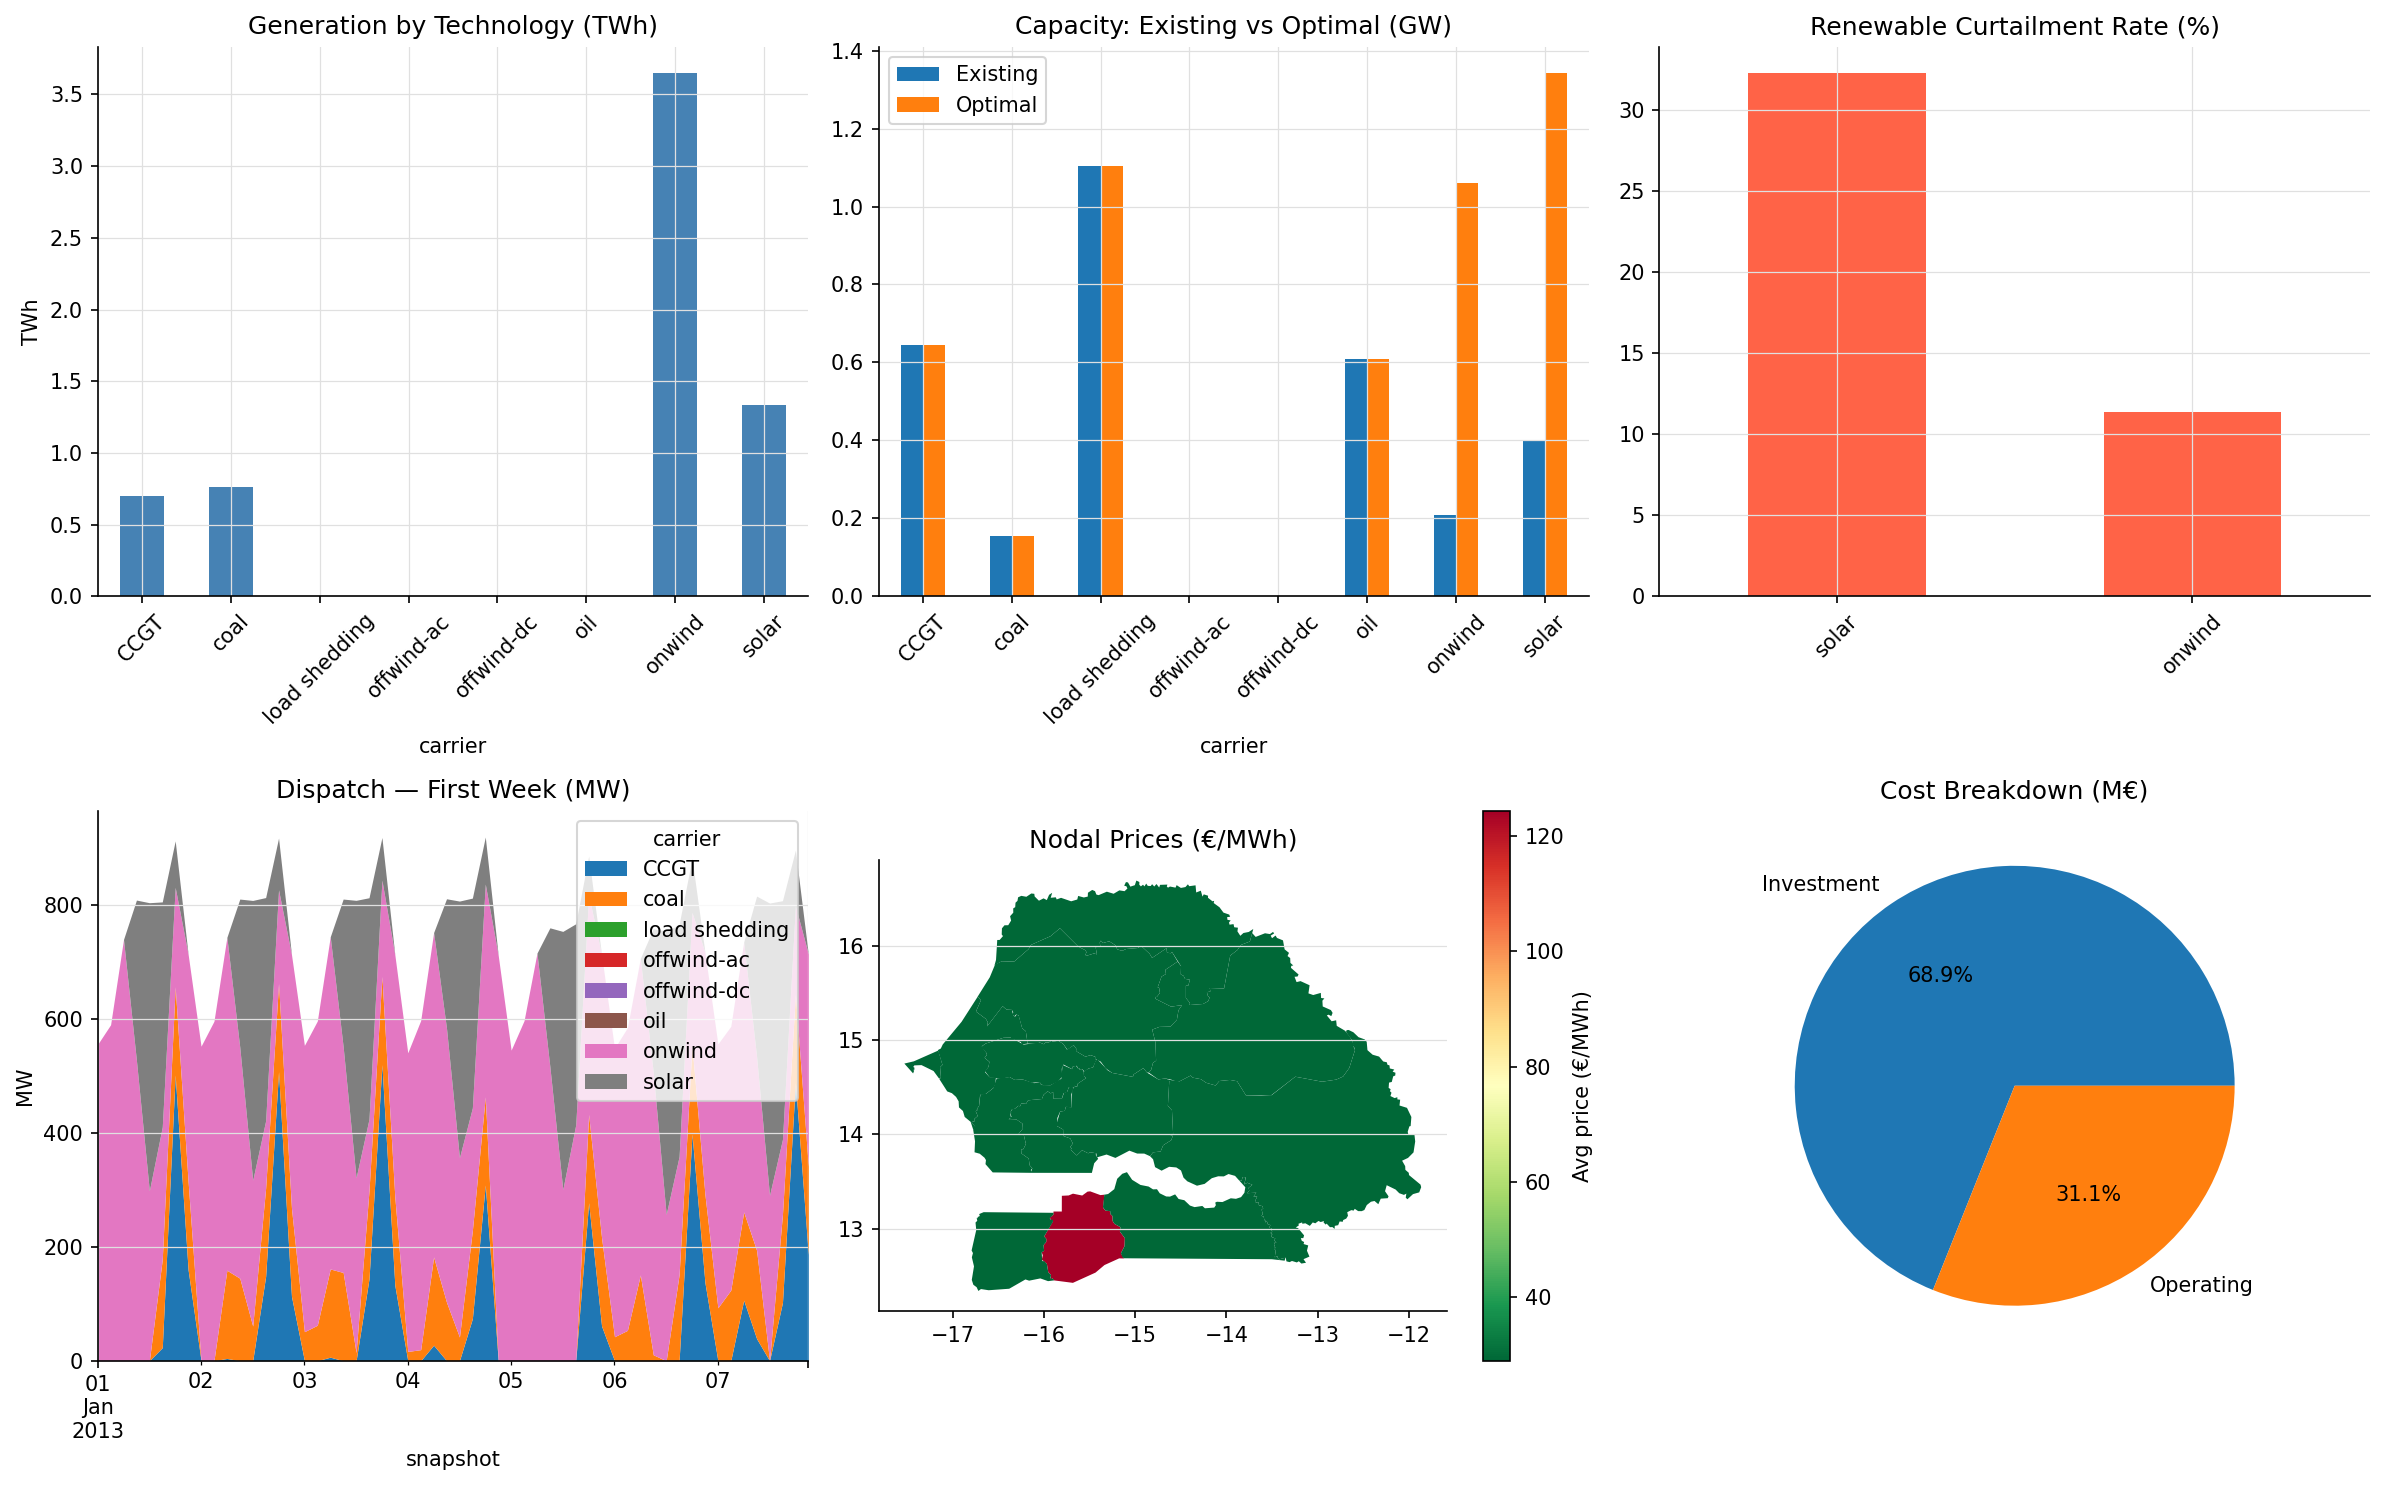

In [58]:
import pypsa
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")
w = n.snapshot_weightings.objective  # snapshot weights for MWh conversion

# ── 1. ECONOMIC OUTPUTS ────────────────────────────────────────────────────────

# Annualised investment cost (CAPEX)
investment_cost = (
    (n.generators.p_nom_opt - n.generators.p_nom) * n.generators.capital_cost
).sum()

# Operating cost (fuel + VOM)
operating_cost = (
    n.generators_t.p.multiply(w, axis=0) * n.generators.marginal_cost
).sum().sum()

# Total system cost
total_cost = investment_cost + operating_cost

print("=== ECONOMIC OUTPUTS ===")
print(f"Total system cost:   €{total_cost/1e6:.1f}M")
print(f"Investment cost:     €{investment_cost/1e6:.1f}M")
print(f"Operating cost:      €{operating_cost/1e6:.1f}M")

# ── 2. DISPATCH RESULTS ────────────────────────────────────────────────────────

# Generation by technology (TWh)
gen_by_carrier = (
    n.generators_t.p.multiply(w, axis=0)
    .sum()
    .groupby(n.generators.carrier)
    .sum() / 1e6
)
print("\n=== DISPATCH RESULTS (TWh) ===")
print(gen_by_carrier.sort_values(ascending=False))

# Battery charge/discharge
if not n.storage_units.empty:
    charge = n.storage_units_t.p.clip(upper=0).multiply(w, axis=0).sum() / 1e6
    discharge = n.storage_units_t.p.clip(lower=0).multiply(w, axis=0).sum() / 1e6
    print("\nBattery discharge (TWh):", discharge.sum().round(3))
    print("Battery charge (TWh):", abs(charge.sum()).round(3))

# ── 3. RENEWABLE CURTAILMENT ───────────────────────────────────────────────────

re_carriers = ["solar", "onwind", "offwind-ac", "offwind-dc"]
curtailment = {}
for carrier in re_carriers:
    gens = n.generators[n.generators.carrier == carrier].index
    if len(gens) == 0:
        continue

    p_nom_opt_total = n.generators.loc[gens, "p_nom_opt"].sum()
    if p_nom_opt_total < 1:   # skip if less than 1 MW installed — numerical noise
        continue

    available = (
        n.generators_t.p_max_pu[gens]
        .multiply(n.generators.loc[gens, "p_nom_opt"])
        .multiply(w, axis=0)
        .sum().sum() / 1e6
    )
    actual = (
        n.generators_t.p[gens].multiply(w, axis=0).sum().sum() / 1e6
    )
    curtailment[carrier] = {
        "available": available, "actual": actual,
        "curtailed": available - actual,
        "rate_%": (available - actual) / available * 100 if available > 0 else 0,
    }

print("\n=== RENEWABLE CURTAILMENT ===")
print(pd.DataFrame(curtailment).T.round(3))

# ── 4. ENVIRONMENTAL OUTPUTS ───────────────────────────────────────────────────

emissions = (
    n.generators_t.p.multiply(w, axis=0)
    .sum()
    .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
    .sum()
) / 1e6  # Mt CO2

annual_demand = n.loads_t.p_set.multiply(w, axis=0).sum().sum() / 1e6  # TWh
emissions_intensity = emissions * 1e6 / (annual_demand * 1e6) * 1e3  # gCO2/kWh

print("\n=== ENVIRONMENTAL OUTPUTS ===")
print(f"CO2 emissions:       {emissions:.3f} Mt CO2")
print(f"Emissions intensity: {emissions_intensity:.1f} gCO2/kWh")

# ── 5. SPATIAL OUTPUTS (nodal prices & line flows) ─────────────────────────────

# Nodal prices (shadow prices, €/MWh)
nodal_prices = n.buses_t.marginal_price.mean()
print("\n=== NODAL PRICES (avg €/MWh) ===")
print(nodal_prices.sort_values(ascending=False).round(2))

# Line utilisation
line_util = (
    n.lines_t.p0.abs() / n.lines.s_nom_opt
).mean().sort_values(ascending=False)
print("\n=== LINE UTILISATION (avg %) ===")
print((line_util * 100).round(1))

# ── 6. PLOTS ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (a) Generation mix
gen_by_carrier.plot.bar(ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Generation by Technology (TWh)")
axes[0,0].set_ylabel("TWh"); axes[0,0].tick_params(axis="x", rotation=45)

# (b) Installed capacity: existing vs optimal
cap = pd.DataFrame({
    "Existing": n.generators.groupby("carrier").p_nom.sum() / 1e3,
    "Optimal":  n.generators.groupby("carrier").p_nom_opt.sum() / 1e3,
}).fillna(0)
cap.plot.bar(ax=axes[0,1])
axes[0,1].set_title("Capacity: Existing vs Optimal (GW)")
axes[0,1].tick_params(axis="x", rotation=45)

# (c) Curtailment rate
curtail_df = pd.DataFrame(curtailment).T["rate_%"].fillna(0)
curtail_df.plot.bar(ax=axes[0,2], color="tomato")
axes[0,2].set_title("Renewable Curtailment Rate (%)")
axes[0,2].tick_params(axis="x", rotation=45)

# (d) Dispatch time series (first week)
dispatch = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().iloc[:56]
dispatch.plot.area(ax=axes[1,0], linewidth=0)
axes[1,0].set_title("Dispatch — First Week (MW)")
axes[1,0].set_ylabel("MW")

# (e) Nodal prices map
import geopandas as gpd
regions = gpd.read_file("resources/bus_regions/regions_onshore_elec_s_14.geojson").set_index("name")
regions["price"] = nodal_prices
regions.plot(column="price", ax=axes[1,1], legend=True,
             legend_kwds={"label": "Avg price (€/MWh)"}, cmap="RdYlGn_r")
axes[1,1].set_title("Nodal Prices (€/MWh)")

# (f) Cost breakdown
cost_items = pd.Series({"Investment": investment_cost/1e6, "Operating": operating_cost/1e6})
cost_items.plot.pie(ax=axes[1,2], autopct="%1.1f%%")
axes[1,2].set_title("Cost Breakdown (M€)")
axes[1,2].set_ylabel("")

plt.tight_layout()
plt.savefig("results/analysis_overview.png", dpi=150, bbox_inches="tight")
plt.show()

INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores


=== ECONOMIC OUTPUTS ===
Total system cost:   €179.3M
Investment cost:     €123.6M
Operating cost:      €55.7M

=== DISPATCH RESULTS (TWh) ===
carrier
onwind           3.651250e+00
solar            1.333291e+00
coal             7.598309e-01
CCGT             6.985734e-01
offwind-ac       6.141746e-14
offwind-dc       3.254559e-14
oil              1.932409e-14
load shedding    6.328472e-17
dtype: float64

=== RENEWABLE CURTAILMENT ===
        available  actual  curtailed  rate_%
solar       1.970   1.333      0.637  32.321
onwind      4.121   3.651      0.470  11.405

=== ENVIRONMENTAL OUTPUTS ===
CO2 emissions:       0.394 Mt CO2
Emissions intensity: 61.1 gCO2/kWh

=== NODAL PRICES (avg €/MWh) ===
Bus
SN.11_1_AC            124.40
SN.11_1_AC battery    122.98
SN.11_1_AC H2          71.74
SN.1_1_AC H2           39.74
SN.14_1_AC H2          39.74
SN.7_1_AC H2           39.73
SN.12_1_AC H2          39.72
SN.5_1_AC H2           39.71
SN.13_1_AC H2          39.71
SN.3_1_AC H2           39.71


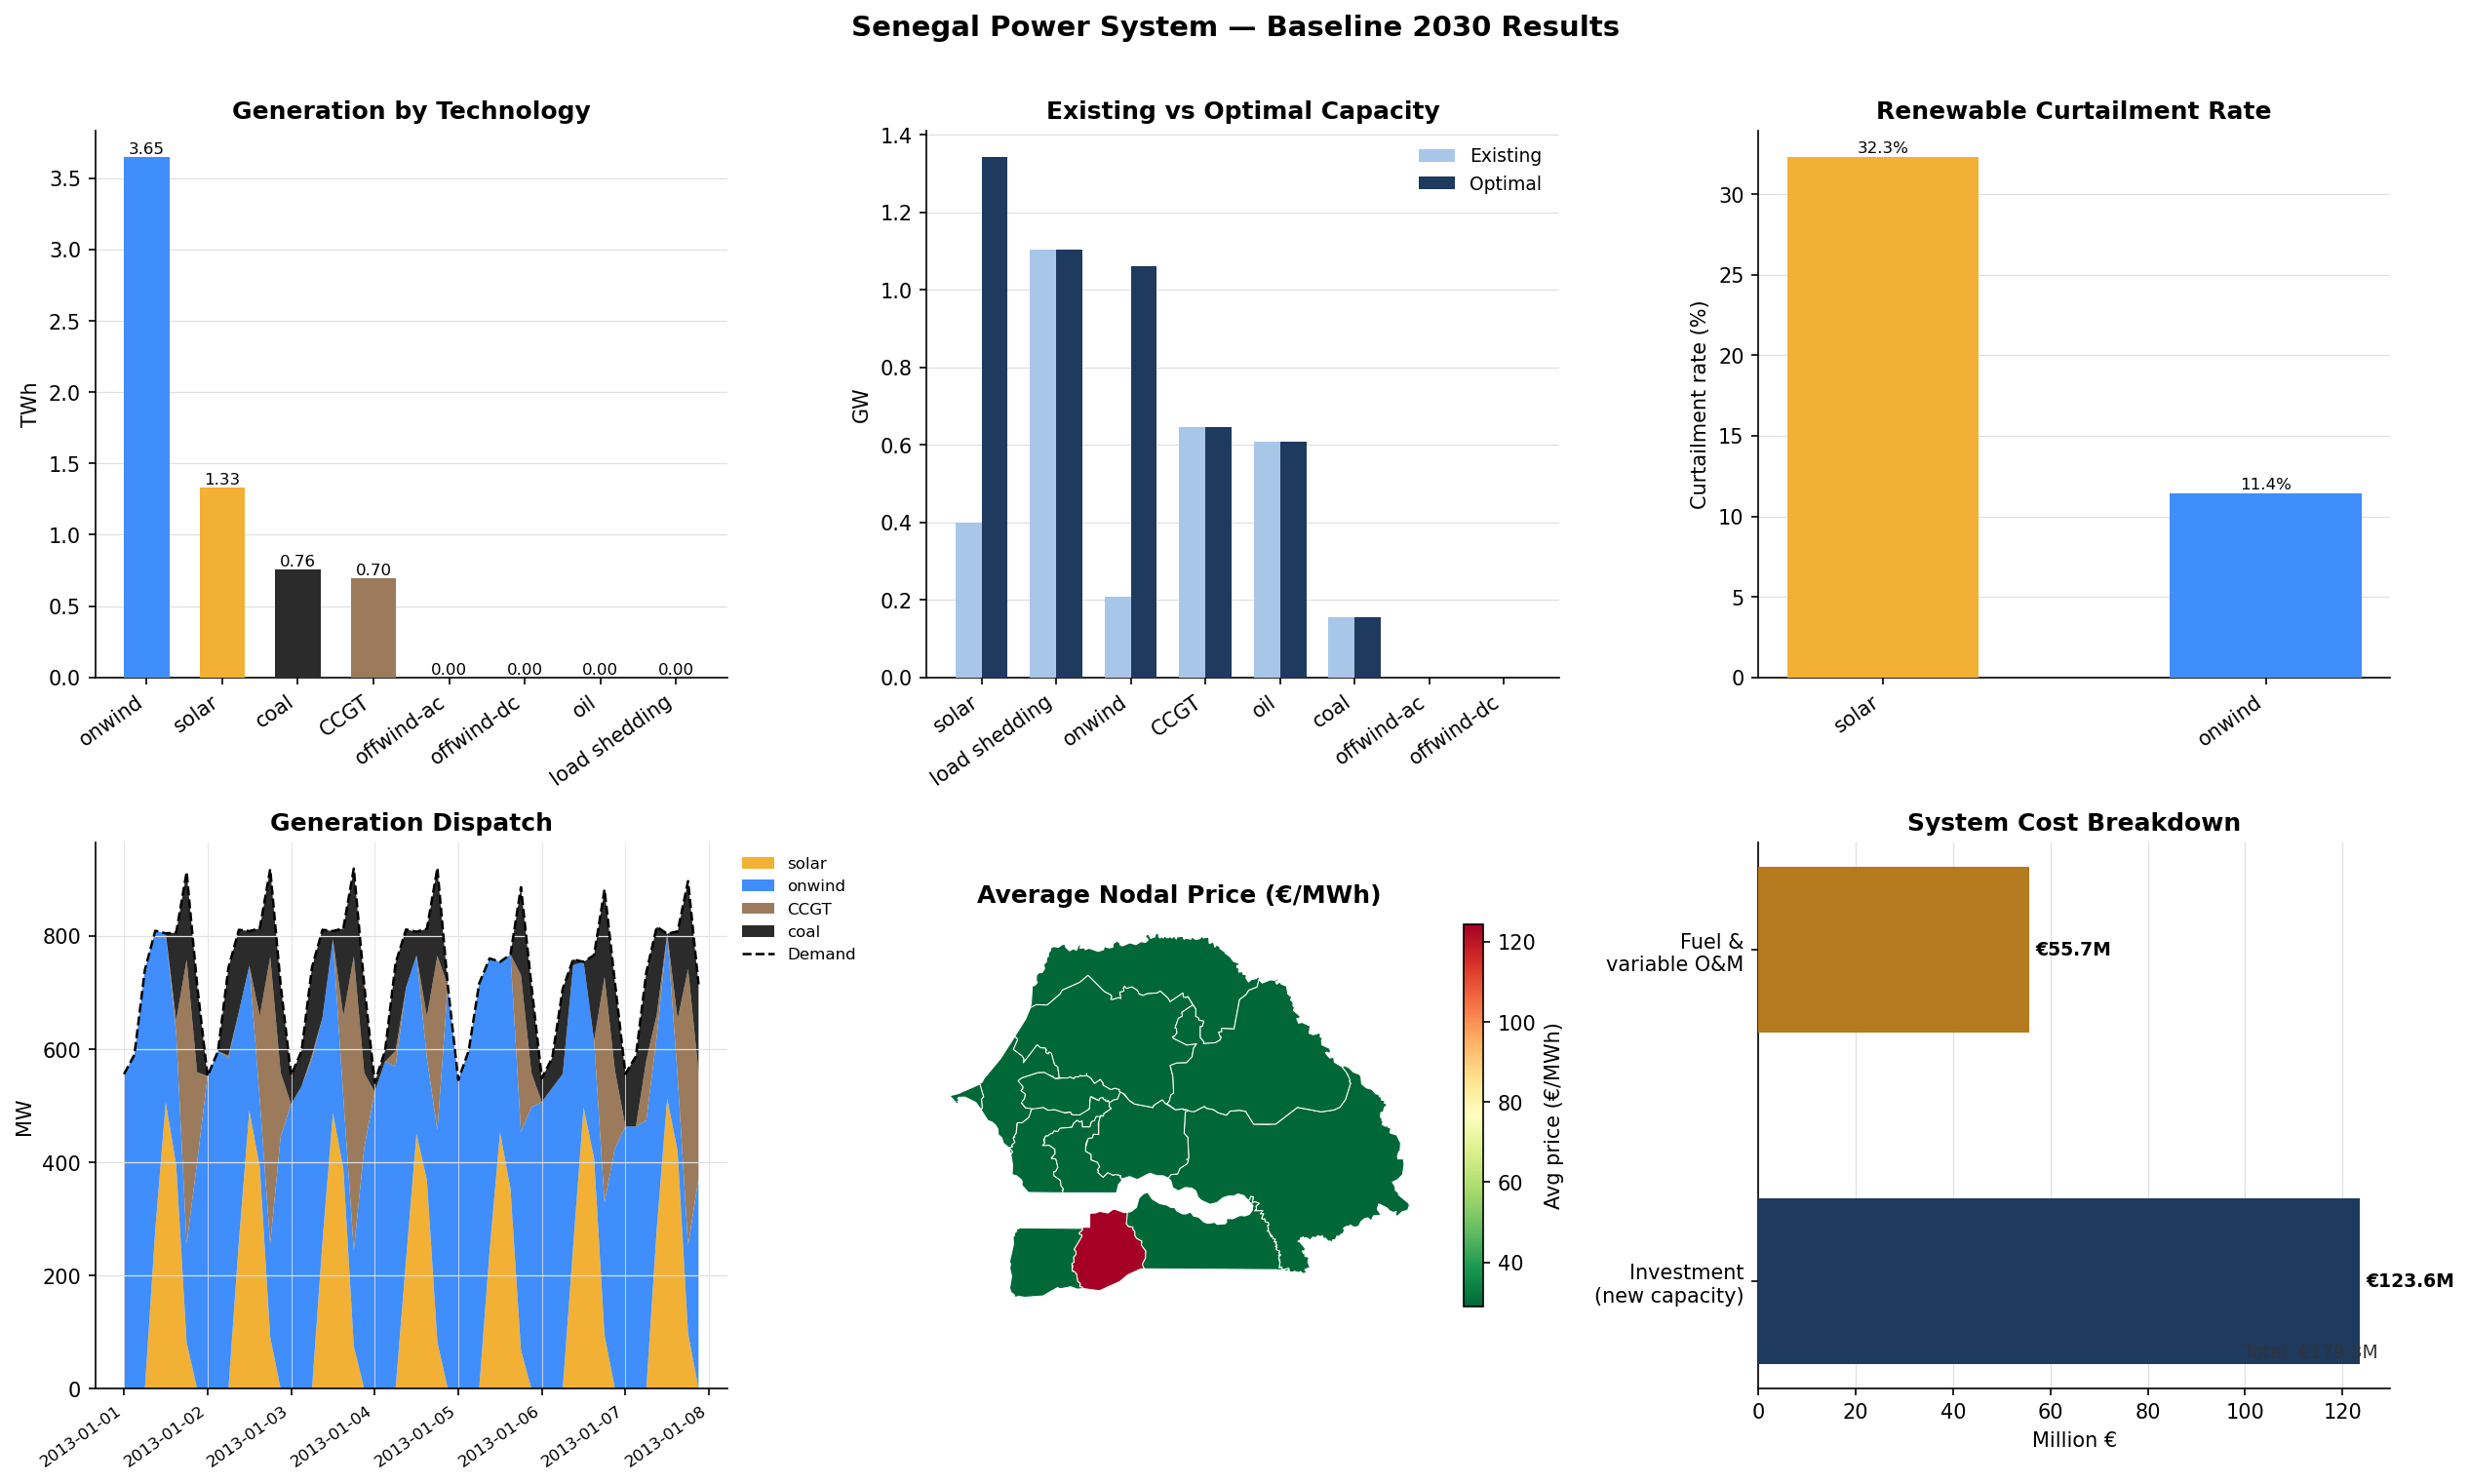

In [59]:
import pypsa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import geopandas as gpd

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "axes.grid.axis":   "y",
    "grid.color":       "#e0e0e0",
    "grid.linewidth":   0.6,
    "figure.dpi":       150,
})

COLORS = {
    "solar":       "#F2B134",
    "onwind":      "#3F8EFC",
    "offwind-ac":  "#1D5B9C",
    "offwind-dc":  "#0A2D6B",
    "hydro":       "#2E8B57",
    "CCGT":        "#9B7B5B",
    "oil":         "#6B6B6B",
    "coal":        "#2B2B2B",
    "load shedding": "#C0392B",
}

# ── Load network ───────────────────────────────────────────────────────────────
n = pypsa.Network("results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc")
w = n.snapshot_weightings.objective

# ── 1. ECONOMIC OUTPUTS ────────────────────────────────────────────────────────
investment_cost = (
    (n.generators.p_nom_opt - n.generators.p_nom) * n.generators.capital_cost
).sum()
operating_cost = (
    n.generators_t.p.multiply(w, axis=0) * n.generators.marginal_cost
).sum().sum()
total_cost = investment_cost + operating_cost

print("=== ECONOMIC OUTPUTS ===")
print(f"Total system cost:   €{total_cost/1e6:.1f}M")
print(f"Investment cost:     €{investment_cost/1e6:.1f}M")
print(f"Operating cost:      €{operating_cost/1e6:.1f}M")

# ── 2. DISPATCH RESULTS ────────────────────────────────────────────────────────
gen_by_carrier = (
    n.generators_t.p.multiply(w, axis=0)
    .sum()
    .groupby(n.generators.carrier)
    .sum() / 1e6
)
print("\n=== DISPATCH RESULTS (TWh) ===")
print(gen_by_carrier.sort_values(ascending=False))

if not n.storage_units.empty:
    charge    = n.storage_units_t.p.clip(upper=0).multiply(w, axis=0).sum() / 1e6
    discharge = n.storage_units_t.p.clip(lower=0).multiply(w, axis=0).sum() / 1e6
    print("\nBattery discharge (TWh):", discharge.sum().round(3))
    print("Battery charge (TWh):",    abs(charge.sum()).round(3))

# ── 3. RENEWABLE CURTAILMENT ───────────────────────────────────────────────────
re_carriers = ["solar", "onwind", "offwind-ac", "offwind-dc"]
curtailment = {}
for carrier in re_carriers:
    gens = n.generators[n.generators.carrier == carrier].index
    if len(gens) == 0:
        continue

    p_nom_opt_total = n.generators.loc[gens, "p_nom_opt"].sum()
    if p_nom_opt_total < 1:   # skip if less than 1 MW installed — numerical noise
        continue

    available = (
        n.generators_t.p_max_pu[gens]
        .multiply(n.generators.loc[gens, "p_nom_opt"])
        .multiply(w, axis=0)
        .sum().sum() / 1e6
    )
    actual = (
        n.generators_t.p[gens].multiply(w, axis=0).sum().sum() / 1e6
    )
    curtailment[carrier] = {
        "available": available, "actual": actual,
        "curtailed": available - actual,
        "rate_%": (available - actual) / available * 100 if available > 0 else 0,
    }
print("\n=== RENEWABLE CURTAILMENT ===")
print(pd.DataFrame(curtailment).T.round(3))

# ── 4. ENVIRONMENTAL OUTPUTS ───────────────────────────────────────────────────
emissions = (
    n.generators_t.p.multiply(w, axis=0)
    .sum()
    .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
    .sum()
) / 1e6
annual_demand       = n.loads_t.p_set.multiply(w, axis=0).sum().sum() / 1e6
emissions_intensity = emissions * 1e6 / (annual_demand * 1e6) * 1e3

print("\n=== ENVIRONMENTAL OUTPUTS ===")
print(f"CO2 emissions:       {emissions:.3f} Mt CO2")
print(f"Emissions intensity: {emissions_intensity:.1f} gCO2/kWh")

# ── 5. SPATIAL OUTPUTS ────────────────────────────────────────────────────────
nodal_prices = n.buses_t.marginal_price.mean()
print("\n=== NODAL PRICES (avg €/MWh) ===")
print(nodal_prices.sort_values(ascending=False).round(2))

line_util = (n.lines_t.p0.abs() / n.lines.s_nom_opt).mean().sort_values(ascending=False)
print("\n=== LINE UTILISATION (avg %) ===")
print((line_util * 100).round(1))

# ── 6. PLOTS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.patch.set_facecolor("white")

# ── (a) Generation mix ────────────────────────────────────────────────────────
ax = axes[0, 0]
gb = gen_by_carrier[gen_by_carrier > 0].sort_values(ascending=False)
bar_colors = [COLORS.get(c, "#aaaaaa") for c in gb.index]
bars = ax.bar(range(len(gb)), gb.values, color=bar_colors, width=0.6, zorder=3)
ax.set_xticks(range(len(gb)))
ax.set_xticklabels(gb.index, rotation=35, ha="right")
ax.set_ylabel("TWh")
ax.set_title("Generation by Technology", fontweight="bold")
for bar, val in zip(bars, gb.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# ── (b) Capacity: existing vs optimal ────────────────────────────────────────
ax = axes[0, 1]
cap = pd.DataFrame({
    "Existing": n.generators.groupby("carrier").p_nom.sum() / 1e3,
    "Optimal":  n.generators.groupby("carrier").p_nom_opt.sum() / 1e3,
}).fillna(0)
cap = cap[cap.max(axis=1) > 0].sort_values("Optimal", ascending=False)
x = np.arange(len(cap))
w_bar = 0.35
ax.bar(x - w_bar / 2, cap["Existing"], w_bar, label="Existing", color="#a8c6e8", zorder=3)
ax.bar(x + w_bar / 2, cap["Optimal"],  w_bar, label="Optimal",  color="#1E3A5F",  zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(cap.index, rotation=35, ha="right")
ax.set_ylabel("GW")
ax.set_title("Existing vs Optimal Capacity", fontweight="bold")
ax.legend(frameon=False, fontsize=9)

# ── (c) Curtailment rate ──────────────────────────────────────────────────────
ax = axes[0, 2]
curtail_df = pd.DataFrame(curtailment).T["rate_%"].fillna(0).sort_values(ascending=False)
bar_colors_c = [COLORS.get(c, "#aaaaaa") for c in curtail_df.index]
bars = ax.bar(range(len(curtail_df)), curtail_df.values,
              color=bar_colors_c, width=0.5, zorder=3)
ax.set_xticks(range(len(curtail_df)))
ax.set_xticklabels(curtail_df.index, rotation=35, ha="right")
ax.set_ylabel("Curtailment rate (%)")
ax.set_title("Renewable Curtailment Rate", fontweight="bold")
for bar, val in zip(bars, curtail_df.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

# ── (d) Dispatch stack — full period ─────────────────────────────────────────
ax = axes[1, 0]
dispatch = (
    n.generators_t.p
    .T.groupby(n.generators.carrier).sum().T
)
cols_ordered = [c for c in COLORS if c in dispatch.columns]
cols_ordered += [c for c in dispatch.columns if c not in cols_ordered]
dispatch = dispatch[cols_ordered]
dispatch = dispatch.loc[:, dispatch.max() > 1]
stack_colors = [COLORS.get(c, "#aaaaaa") for c in dispatch.columns]
ax.stackplot(dispatch.index, dispatch.T.values,
             labels=dispatch.columns, colors=stack_colors)
demand = n.loads_t.p_set.sum(axis=1)
ax.plot(demand.index, demand.values, color="black", linewidth=1.2,
        linestyle="--", label="Demand", zorder=5)
ax.set_ylabel("MW")
ax.set_title("Generation Dispatch", fontweight="bold")
ax.set_xlabel("")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0),
          frameon=False, fontsize=8, ncol=1)
ax.grid(axis="x", color="#e0e0e0", linewidth=0.4)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)  # ← add this

# ── (e) Nodal prices map ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.set_facecolor("#d6e8f5")
regions = (
    gpd.read_file("resources/bus_regions/regions_onshore_elec_s_14.geojson")
    .set_index("name")
)
regions["price"] = nodal_prices
regions.plot(
    column="price", ax=ax, legend=True, cmap="RdYlGn_r",
    edgecolor="white", linewidth=0.5,
    legend_kwds={"label": "Avg price (€/MWh)", "shrink": 0.7},
    missing_kwds={"color": "#cccccc"},
)
ax.set_title("Average Nodal Price (€/MWh)", fontweight="bold")
ax.set_axis_off()

# ── (f) Cost breakdown — horizontal bar ──────────────────────────────────────
ax = axes[1, 2]
ax.set_facecolor("white")
cost_items = pd.Series({
    "Investment\n(new capacity)": investment_cost / 1e6,
    "Fuel &\nvariable O&M":       operating_cost  / 1e6,
})
bar_colors_f = ["#1E3A5F", "#B5791E"]
bars = ax.barh(range(len(cost_items)), cost_items.values,
               color=bar_colors_f, height=0.5, zorder=3)
ax.set_yticks(range(len(cost_items)))
ax.set_yticklabels(cost_items.index)
ax.set_xlabel("Million €")
ax.set_title("System Cost Breakdown", fontweight="bold")
ax.grid(axis="x", color="#e0e0e0", linewidth=0.6)
ax.grid(axis="y", visible=False)
for bar, val in zip(bars, cost_items.values):
    ax.text(bar.get_width() + cost_items.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"€{val:.1f}M", va="center", fontsize=9, fontweight="bold")
total_label = f"Total: €{(investment_cost + operating_cost)/1e6:.1f}M"
ax.text(0.98, 0.05, total_label, transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, color="#333333")

plt.suptitle("Senegal Power System — Baseline 2030 Results",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("test/analysis_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
"""
BESS in Senegal — results analysis for PyPSA-Earth outputs
============================================================

Six functions, one per results slide recommended for the midterm deck:

  1. cost_breakdown / plot_cost_comparison   -> Slide: Total system cost
  2. plot_dispatch_and_soc                   -> Slide: Dispatch & BESS operation
  3. plot_value_stack                        -> Slide: Value stack decomposition
  4. curtailment_summary / plot_curtailment  -> Slide: Curtailment & RE integration
  5. plot_sensitivity_heatmap                -> Slide: Net benefit vs CAPEX/discount rate
  6. spatial_outputs / plot_nodal_prices      -> Slide: Spatial outputs (optional)

Usage
-----
    import pypsa
    from bess_results_analysis import *

    n_base = pypsa.Network("results/baseline_no_bess.nc")
    n_bess = pypsa.Network("results/bess_optimal.nc")

    plot_cost_comparison({"No BESS": n_base, "With BESS": n_bess},
                          save="fig_cost_comparison.png")

    plot_dispatch_and_soc(n_bess, start="2030-03-01", end="2030-03-08",
                           save="fig_dispatch_week.png")

    plot_value_stack(n_base, n_bess, voll=250, carbon_price=0,
                      save="fig_value_stack.png")

    plot_curtailment({"Low RE": n_low, "Policy-aligned": n_mid, "High RE": n_high},
                      save="fig_curtailment.png")

Assumptions / things to check against your own network setup
---------------------------------------------------------------
- Networks are already solved (`n.optimize()` has run) so `n.objective`,
  `n.generators_t.p`, `n.storage_units_t.state_of_charge`, etc. are populated.
- BESS is modelled as `n.storage_units` (or `n.stores` — see NOTE in
  `get_bess_names`) with carrier == "battery" by default; change
  `BESS_CARRIER` below if you used a different label.
- Unserved energy is modelled via a generator with carrier == "load_shedding"
  (PyPSA-Earth's default) — change `VOLL_CARRIER` if different.
- Fuel cost = `marginal_cost` of thermal generators * dispatch. If you track
  fuel cost separately, swap in your own column.
- `n.snapshot_weightings` is respected everywhere so results are correct for
  both hourly and sub-hourly / representative-period runs.
"""

from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ----------------------------------------------------------------------
# Output folder — all figures are saved here
# ----------------------------------------------------------------------
SAVE_DIR = "test"
os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# Config — adjust to match your network's carrier / component naming
# ----------------------------------------------------------------------
BESS_CARRIER = "battery"
VOLL_CARRIER = "load_shedding"     # carrier name for unserved-energy generator, if used
RE_CARRIERS = ["solar", "onwind", "offwind", "hydro"]
THERMAL_CARRIERS = ["oil", "HFO", "diesel", "gas", "OCGT", "CCGT", "coal"]

CARRIER_COLORS = {
    "solar": "#F2B134", "onwind": "#3F8EFC", "offwind": "#1D5B9C",
    "hydro": "#2E8B57", "gas": "#7A6C5D", "OCGT": "#7A6C5D", "CCGT": "#5C4B3D",
    "oil": "#4A4A4A", "HFO": "#4A4A4A", "diesel": "#6B5B4D",
    "battery": "#B5791E", "load_shedding": "#C0392B",
}


def _weighted(series: pd.Series, weights: pd.Series) -> float:
    """Sum a snapshot-indexed series weighted by snapshot duration (handles sub-hourly runs)."""
    return float((series * weights).sum())


# ----------------------------------------------------------------------
# 1. TOTAL SYSTEM COST
# ----------------------------------------------------------------------
def cost_breakdown(n) -> pd.Series:
    """Decompose a solved network's total annual system cost into four components.

    Returns a pandas Series with index:
    ['investment', 'fixed_om', 'fuel_variable_om', 'unserved_energy', 'total']
    All values in the network's cost currency (usually USD or EUR, per your `costs.csv`).
    """
    w = n.snapshot_weightings.generators

    # Annualised investment: capital_cost * optimal capacity, for extendable assets only
    inv = 0.0
    for comp in ["generators", "storage_units", "stores", "lines", "links"]:
        static = getattr(n, comp)
        if static.empty or "capital_cost" not in static.columns:
            continue
        p_nom_opt_col = "p_nom_opt" if "p_nom_opt" in static.columns else None
        e_nom_opt_col = "e_nom_opt" if "e_nom_opt" in static.columns else None
        if p_nom_opt_col:
            inv += float((static["capital_cost"] * static[p_nom_opt_col]).sum())
        elif e_nom_opt_col:
            inv += float((static["capital_cost"] * static[e_nom_opt_col]).sum())

    # Fixed O&M (if you track it separately from capital_cost, adjust here)
    fixed_om = 0.0
    if "fixed_om_cost" in n.generators.columns:
        fixed_om = float((n.generators["fixed_om_cost"] * n.generators.get("p_nom_opt", n.generators["p_nom"])).sum())

    # Fuel & variable O&M: marginal_cost * dispatch, summed over weighted snapshots
    fuel_var = 0.0
    if not n.generators_t.p.empty:
        mc = n.generators["marginal_cost"]
        fuel_var += _weighted((n.generators_t.p * mc).sum(axis=1), w)
    if not n.links_t.p0.empty and "marginal_cost" in n.links.columns:
        mc_l = n.links["marginal_cost"]
        fuel_var += _weighted((n.links_t.p0 * mc_l).sum(axis=1), w)

    # Unserved energy penalty
    unserved = 0.0
    ls = n.generators[n.generators.carrier == VOLL_CARRIER].index
    if len(ls):
        unserved = _weighted(n.generators_t.p[ls].sum(axis=1) * n.generators.loc[ls, "marginal_cost"].mean(), w)

    total = inv + fixed_om + fuel_var + unserved
    return pd.Series(
        {"investment": inv, "fixed_om": fixed_om, "fuel_variable_om": fuel_var,
         "unserved_energy": unserved, "total": total}
    )


def plot_cost_comparison(scenarios: dict[str, "pypsa.Network"], save: str | None = None):
    """Stacked bar chart of cost breakdown across N named scenarios (e.g. {'No BESS': n1, 'With BESS': n2})."""
    rows = {name: cost_breakdown(n).drop("total") for name, n in scenarios.items()}
    df = pd.DataFrame(rows).T / 1e6  # -> million currency units

    fig, ax = plt.subplots(figsize=(7, 4.5))
    df.plot(kind="bar", stacked=True, ax=ax,
            color=["#1E3A5F", "#5B7FA6", "#B5791E", "#C0392B"])
    ax.set_ylabel("Annual system cost (million currency units)")
    ax.set_title("Total system cost by component")
    ax.legend(["Investment", "Fixed O&M", "Fuel & variable O&M", "Unserved energy"],
              loc="upper right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    for i, (name, n) in enumerate(scenarios.items()):
        total = df.loc[name].sum()
        ax.text(i, total * 1.02, f"{total:,.1f}M", ha="center", fontsize=9, fontweight="bold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200)
    return fig


# ----------------------------------------------------------------------
# 2. DISPATCH & BESS OPERATION
# ----------------------------------------------------------------------
def get_bess_names(n) -> list[str]:
    names = list(n.storage_units[n.storage_units.carrier == BESS_CARRIER].index)
    if not names and hasattr(n, "stores"):
        names = list(n.stores[n.stores.carrier == BESS_CARRIER].index)  # if modelled as Store + Link pair
    return names


def plot_dispatch_and_soc(n, start: str, end: str, save: str | None = None):
    """Stacked generation dispatch + BESS charge/discharge + state of charge, for a date window."""
    gen = n.generators_t.p.loc[start:end]
    carriers = n.generators.carrier
    by_carrier = gen.T.groupby(carriers).sum().T  # snapshots x carrier

    bess = get_bess_names(n)
    soc = None
    charge_discharge = None
    if bess and hasattr(n, "storage_units_t"):
        charge_discharge = n.storage_units_t.p[bess].sum(axis=1).loc[start:end]
        soc = n.storage_units_t.state_of_charge[bess].sum(axis=1).loc[start:end]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    colors = [CARRIER_COLORS.get(c, "#999999") for c in by_carrier.columns]
    ax1.stackplot(by_carrier.index, by_carrier.T.values, labels=by_carrier.columns, colors=colors)
    if charge_discharge is not None:
        ax1.plot(charge_discharge.index, charge_discharge.values, color="#B5791E",
                  linewidth=1.8, label="BESS (+discharge / -charge)")
    ax1.axhline(0, color="black", linewidth=0.6)
    ax1.set_ylabel("Power (MW)")
    ax1.set_title(f"Generation dispatch and BESS operation, {start} to {end}")
    ax1.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8)
    ax1.spines[["top", "right"]].set_visible(False)

    if soc is not None:
        ax2.plot(soc.index, soc.values, color="#2F6B3A", linewidth=1.6)
        ax2.fill_between(soc.index, 0, soc.values, color="#2F6B3A", alpha=0.15)
        ax2.set_ylabel("BESS SoC (MWh)")
    ax2.set_xlabel("")
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200, bbox_inches="tight")
    return fig


# ----------------------------------------------------------------------
# 3. VALUE STACK DECOMPOSITION
# ----------------------------------------------------------------------
def value_stack(n_base, n_bess, voll: float = 250.0, carbon_price: float = 0.0) -> pd.Series:
    """Decompose the system cost saving between a no-BESS and a with-BESS network
    into value streams. Approximate (counterfactual-difference) method:

    - fuel_savings          : reduction in fuel & variable O&M cost
    - curtailment_reduction : reduction in curtailed RE energy, valued at its
                               fuel-cost-equivalent (avoided need to run thermal
                               plant that curtailment would otherwise have required)
    - avoided_capacity      : reduction in generation capacity investment
                               (thermal + RE) between the two networs
    - reliability_value     : reduction in unserved energy, valued at VOLL
    - emissions_value       : reduction in CO2 emissions, valued at carbon_price
                               (0 by default — set if your thesis prices carbon)

    Returns a pandas Series with these five components plus 'total_saving' and
    'bess_lifecycle_cost' (= investment + fixed O&M of the BESS itself, for
    comparison against the sum of the value streams).
    """
    cb_base = cost_breakdown(n_base)
    cb_bess = cost_breakdown(n_bess)

    fuel_savings = cb_base["fuel_variable_om"] - cb_bess["fuel_variable_om"]
    reliability_value = (cb_base["unserved_energy"] - cb_bess["unserved_energy"])

    curt_base = curtailment_summary(n_base)["curtailed_mwh"].sum()
    curt_bess = curtailment_summary(n_bess)["curtailed_mwh"].sum()
    # value curtailment reduction at the average thermal marginal cost as a proxy
    thermal = n_bess.generators[n_bess.generators.carrier.isin(THERMAL_CARRIERS)]
    avg_thermal_mc = thermal["marginal_cost"].mean() if len(thermal) else 0.0
    curtailment_reduction = (curt_base - curt_bess) * avg_thermal_mc

    avoided_capacity = cb_base["investment"] - cb_bess["investment"]
    # remove the BESS's own investment from "avoided capacity" so it isn't double counted
    bess_capex = 0.0
    bess_names = get_bess_names(n_bess)
    if bess_names:
        su = n_bess.storage_units.loc[bess_names]
        bess_capex = float((su["capital_cost"] * su.get("p_nom_opt", su["p_nom"])).sum())
    avoided_capacity += bess_capex  # add back so BESS capex isn't netted into "avoided capacity"

    em_base = emissions_summary(n_base)["total_tCO2"]
    em_bess = emissions_summary(n_bess)["total_tCO2"]
    emissions_value = (em_base - em_bess) * carbon_price

    total_saving = fuel_savings + curtailment_reduction + avoided_capacity + reliability_value + emissions_value
    bess_lifecycle_cost = bess_capex + cb_bess["fixed_om"]  # extend with degradation/replacement if modelled

    return pd.Series({
        "fuel_savings": fuel_savings,
        "curtailment_reduction": curtailment_reduction,
        "avoided_capacity": avoided_capacity,
        "reliability_value": reliability_value,
        "emissions_value": emissions_value,
        "total_saving": total_saving,
        "bess_lifecycle_cost": bess_lifecycle_cost,
        "net_system_benefit": total_saving - bess_lifecycle_cost,
    })


def plot_value_stack(n_base, n_bess, voll: float = 250.0, carbon_price: float = 0.0, save: str | None = None):
    vs = value_stack(n_base, n_bess, voll=voll, carbon_price=carbon_price) / 1e6  # -> million units
    components = ["fuel_savings", "curtailment_reduction", "avoided_capacity",
                  "reliability_value", "emissions_value"]
    labels = ["Fuel\nsavings", "Curtailment\nreduction", "Avoided\ncapacity",
              "Reliability\nvalue", "Emissions\nvalue"]
    values = vs[components].values

    fig, ax = plt.subplots(figsize=(8, 4.5))
    cum = np.cumsum(np.concatenate([[0], values]))
    colors = ["#2F6B3A" if v >= 0 else "#C0392B" for v in values]
    for i, v in enumerate(values):
        ax.bar(i, v, bottom=cum[i] if v >= 0 else cum[i] + v, color=colors[i], width=0.6)
    # net benefit bar and BESS cost bar for reference
    ax.bar(len(values), vs["bess_lifecycle_cost"], color="#4B3A6E", width=0.6)
    ax.bar(len(values) + 1, vs["net_system_benefit"], color="#1E3A5F", width=0.6)

    ax.set_xticks(range(len(values) + 2))
    ax.set_xticklabels(labels + ["BESS\nlifecycle cost", "Net system\nbenefit"])
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("Million currency units / year")
    ax.set_title("BESS value stack vs. lifecycle cost")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200)
    return fig


# ----------------------------------------------------------------------
# 4. CURTAILMENT & RE INTEGRATION
# ----------------------------------------------------------------------
def curtailment_summary(n) -> pd.DataFrame:
    """Curtailed energy (MWh) and curtailment rate (%) by renewable carrier."""
    w = n.snapshot_weightings.generators
    re_gens = n.generators[n.generators.carrier.isin(RE_CARRIERS)]
    if re_gens.empty:
        return pd.DataFrame(columns=["available_mwh", "dispatched_mwh", "curtailed_mwh", "curtailment_rate_pct"])

    avail = (n.generators_t.p_max_pu[re_gens.index] * re_gens["p_nom_opt"].reindex(re_gens.index).fillna(re_gens["p_nom"]))
    avail_energy = avail.multiply(w, axis=0).T.groupby(re_gens.carrier).sum().sum(axis=1)
    dispatched = n.generators_t.p[re_gens.index].multiply(w, axis=0).T.groupby(re_gens.carrier).sum().sum(axis=1)
    curtailed = (avail_energy - dispatched).clip(lower=0)
    rate = (curtailed / avail_energy.replace(0, np.nan) * 100).fillna(0)

    return pd.DataFrame({
        "available_mwh": avail_energy, "dispatched_mwh": dispatched,
        "curtailed_mwh": curtailed, "curtailment_rate_pct": rate,
    })


def plot_curtailment(scenarios: dict[str, "pypsa.Network"], save: str | None = None):
    """Grouped bar chart: curtailment rate (%) by RE carrier, across named scenarios."""
    data = {name: curtailment_summary(n)["curtailment_rate_pct"] for name, n in scenarios.items()}
    df = pd.DataFrame(data)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    df.plot(kind="bar", ax=ax, color=[CARRIER_COLORS.get(name.lower(), None) for name in df.columns] or None)
    ax.set_ylabel("Curtailment rate (%)")
    ax.set_title("Renewable curtailment by scenario")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Scenario", frameon=False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200)
    return fig


# ----------------------------------------------------------------------
# Emissions (used by value_stack; also useful standalone)
# ----------------------------------------------------------------------
def emissions_summary(n) -> pd.Series:
    w = n.snapshot_weightings.generators
    if "co2_emissions" not in n.carriers.columns:
        return pd.Series({"total_tCO2": 0.0, "intensity_kgCO2_per_MWh": 0.0})
    ef = n.carriers["co2_emissions"]  # tCO2/MWh_thermal, approx
    carrier_of_gen = n.generators.carrier
    factor = carrier_of_gen.map(ef).fillna(0)
    emissions = _weighted((n.generators_t.p * factor).sum(axis=1), w)
    total_demand = _weighted(n.loads_t.p_set.sum(axis=1), w)
    intensity = (emissions * 1000 / total_demand) if total_demand else 0.0  # kg/MWh
    return pd.Series({"total_tCO2": emissions, "intensity_kgCO2_per_MWh": intensity})


# ----------------------------------------------------------------------
# 5. SENSITIVITY: net system benefit vs BESS CAPEX / discount rate
# ----------------------------------------------------------------------
def plot_sensitivity_heatmap(results_grid: pd.DataFrame, save: str | None = None):
    """`results_grid` = DataFrame with columns ['capex_usd_per_kwh', 'discount_rate',
    'net_system_benefit_musd'] — one row per (capex, discount rate) run you've already
    solved. This function only plots; running the CAPEX/discount-rate sweep itself means
    re-solving your PyPSA network once per grid point (see note below).

    NOTE: to generate `results_grid`, loop over your parameter grid, set
    `n.storage_units.loc[bess, "capital_cost"] = annualised_cost(capex, discount_rate, lifetime)`
    before each `n.optimize()` call, then record `value_stack(...)["net_system_benefit"]`.
    """
    pivot = results_grid.pivot(index="discount_rate", columns="capex_usd_per_kwh",
                                values="net_system_benefit_musd")
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
                    vmin=-abs(pivot.values).max(), vmax=abs(pivot.values).max())
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:.0f}" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{r:.0%}" for r in pivot.index])
    ax.set_xlabel("Battery CAPEX (USD/kWh)")
    ax.set_ylabel("Discount rate")
    ax.set_title("Net system benefit (million USD/year)")
    # zero-crossing contour = breakeven line
    cs = ax.contour(range(len(pivot.columns)), range(len(pivot.index)), pivot.values,
                     levels=[0], colors="black", linewidths=1.5)
    ax.clabel(cs, fmt="breakeven")
    fig.colorbar(im, ax=ax, label="Million USD/year")
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200)
    return fig


def annualised_cost(capex_per_unit: float, discount_rate: float, lifetime_years: float) -> float:
    """Standard capital recovery factor annualisation, for use inside a CAPEX/discount-rate sweep."""
    if discount_rate == 0:
        return capex_per_unit / lifetime_years
    crf = discount_rate / (1 - (1 + discount_rate) ** (-lifetime_years))
    return capex_per_unit * crf


# ----------------------------------------------------------------------
# 6. SPATIAL OUTPUTS (optional slide)
# ----------------------------------------------------------------------
def plot_nodal_prices(n, save: str | None = None):
    """Duration curve of nodal shadow prices (marginal prices) at each bus."""
    prices = n.buses_t.marginal_price
    if prices.empty:
        raise ValueError("No marginal prices found — check that the network was solved with duals enabled.")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for bus in prices.columns:
        sorted_prices = prices[bus].sort_values(ascending=False).reset_index(drop=True)
        ax.plot(sorted_prices.index / len(sorted_prices) * 100, sorted_prices.values,
                linewidth=1, alpha=0.7, label=bus)
    ax.set_xlabel("% of hours")
    ax.set_ylabel("Nodal price (currency/MWh)")
    ax.set_title("Nodal price duration curves")
    ax.spines[["top", "right"]].set_visible(False)
    if len(prices.columns) <= 12:
        ax.legend(fontsize=7, loc="upper right", ncol=2, frameon=False)
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(SAVE_DIR, save), dpi=200)
    return fig


if __name__ == "__main__":
    print(__doc__)


BESS in Senegal — results analysis for PyPSA-Earth outputs

Six functions, one per results slide recommended for the midterm deck:

  1. cost_breakdown / plot_cost_comparison   -> Slide: Total system cost
  2. plot_dispatch_and_soc                   -> Slide: Dispatch & BESS operation
  3. plot_value_stack                        -> Slide: Value stack decomposition
  4. curtailment_summary / plot_curtailment  -> Slide: Curtailment & RE integration
  5. plot_sensitivity_heatmap                -> Slide: Net benefit vs CAPEX/discount rate
  6. spatial_outputs / plot_nodal_prices      -> Slide: Spatial outputs (optional)

Usage
-----
    import pypsa
    from bess_results_analysis import *

    n_base = pypsa.Network("results/baseline_no_bess.nc")
    n_bess = pypsa.Network("results/bess_optimal.nc")

    plot_cost_comparison({"No BESS": n_base, "With BESS": n_bess},
                          save="fig_cost_comparison.png")

    plot_dispatch_and_soc(n_bess, start="2030-03-01", end="2030-0

In [5]:
import pypsa

n = pypsa.Network("/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc")


INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads


In [6]:
# Overview
print(n)

# What's installed (generators, capacities)
print(n.generators[["carrier", "bus", "p_nom", "p_nom_opt"]])

# Dispatch results (hourly generation per generator)
n.generators_t.p.head()

# Total generation by carrier
n.generators_t.p.sum().groupby(n.generators.carrier).sum() / 1e3  # GWh

# Electricity prices (marginal cost at each bus)
n.buses_t.marginal_price.head()

# Load shedding (if any)
n.generators_t.p.filter(like="load").sum()

# Stores (BESS — should be ~0 for baseline)
print(n.stores[["carrier", "e_nom_opt"]])



PyPSA Network
Components:
 - Bus: 13
 - Carrier: 9
 - Generator: 48
 - GlobalConstraint: 1
 - Line: 16
 - Load: 13
Snapshots: 8760
                                carrier         bus       p_nom    p_nom_opt
Generator                                                                   
SN.10_1_AC onwind                onwind  SN.10_1_AC   12.207692  1145.645951
SN.10_1_AC solar                  solar  SN.10_1_AC   32.546923   208.393166
SN.11_1_AC onwind                onwind  SN.11_1_AC   12.207692     0.000157
SN.11_1_AC solar                  solar  SN.11_1_AC   16.546923     0.002798
SN.12_1_AC oil                      oil  SN.12_1_AC   54.000000    66.602921
SN.12_1_AC onwind                onwind  SN.12_1_AC   12.207692     0.000322
SN.12_1_AC solar                  solar  SN.12_1_AC   16.546923     0.003924
SN.13_1_AC CCGT                    CCGT  SN.13_1_AC  235.000000   666.561174
SN.13_1_AC coal                    coal  SN.13_1_AC   30.000000    30.000006
SN.13_1_AC onwind     

INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/1155898425.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  senegal = countries[countries.geometry.intersects(regions.unary_union)]


TypeError: Axes.pie() got an unexpected keyword argument 'zorder'

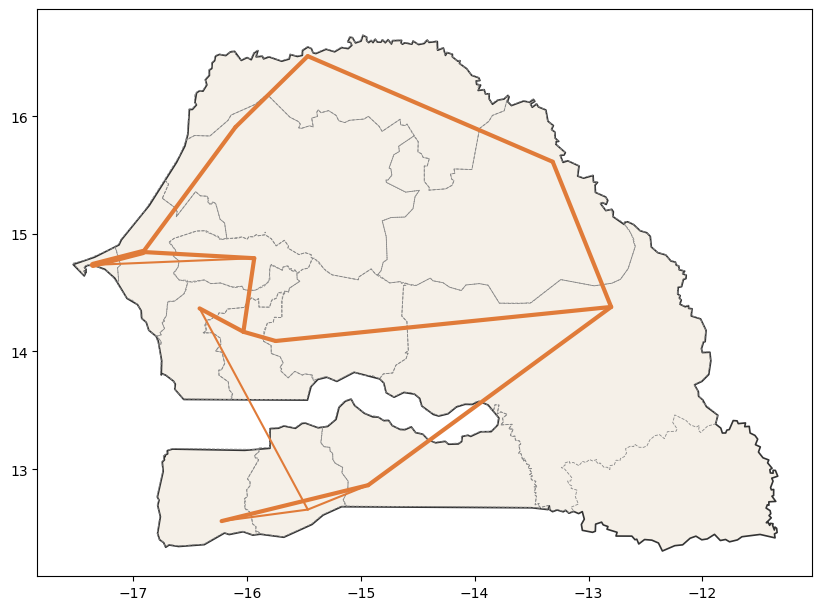

In [8]:
import pypsa
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

SAVE_DIR = "test"
os.makedirs(SAVE_DIR, exist_ok=True)

NETWORK_PATH = "/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc"
REGIONS_PATH = "/Users/william/thesis/pypsa-earth/resources/bus_regions/regions_onshore_elec_s_14.geojson"
SHAPES_PATH  = "/Users/william/thesis/pypsa-earth/resources/shapes/country_shapes.geojson"

n = pypsa.Network(NETWORK_PATH)
regions   = gpd.read_file(REGIONS_PATH)
countries = gpd.read_file(SHAPES_PATH)
# Replace line 17 with:
senegal = countries[countries.geometry.intersects(regions.unary_union)]


fig, ax = plt.subplots(figsize=(10, 8))

senegal.plot(ax=ax, color="#f5f0e8", edgecolor="#333333", linewidth=1.2, zorder=1)
regions.plot(ax=ax, color="none", edgecolor="#888888", linewidth=0.6, linestyle="--", zorder=2)

# transmission lines
for _, line in n.lines.iterrows():
    b0 = n.buses.loc[line.bus0]
    b1 = n.buses.loc[line.bus1]
    lw = 1.5 + 3 * line.s_nom / n.lines.s_nom.max()
    ax.plot([b0.x, b1.x], [b0.y, b1.y],
            color="#e07b39", linewidth=lw, zorder=3, solid_capstyle="round")

# pie charts at each bus (size = installed capacity by carrier)
carrier_colors = {
    "solar": "#f4d03f", "onwind": "#5dade2", "oil": "#7f8c8d",
    "OCGT": "#e74c3c", "CCGT": "#c0392b", "coal": "#2c3e50",
    "biomass": "#27ae60", "hydro": "#1a5276",
}

bus_capacity = n.generators.groupby("bus")["p_nom_opt"].sum()
present_carriers = set()

for bus_id, bus in n.buses.iterrows():
    gens = n.generators[n.generators.bus == bus_id]
    sizes = gens.groupby("carrier")["p_nom_opt"].sum()
    sizes = sizes[sizes > 1]
    if sizes.empty:
        continue
    present_carriers |= set(sizes.index)
    radius = 0.12 * (sizes.sum() / bus_capacity.max()) ** 0.5 + 0.04
    colors = [carrier_colors.get(c, "#bdc3c7") for c in sizes.index]
    ax.pie(sizes.values, center=(bus.x, bus.y), radius=radius, colors=colors,
           wedgeprops=dict(linewidth=0.4, edgecolor="white"), zorder=5)
    ax.annotate(bus_id, (bus.x, bus.y), xytext=(3, 3),
                textcoords="offset points", fontsize=6.5, color="#222222", zorder=6)

legend_patches = [mpatches.Patch(color=carrier_colors.get(c, "#bdc3c7"), label=c)
                  for c in sorted(present_carriers)]
legend_patches.append(plt.Line2D([0], [0], color="#e07b39", linewidth=2, label="Transmission line"))
ax.legend(handles=legend_patches, loc="lower left", fontsize=9,
          framealpha=0.9, title="Technology", title_fontsize=9)

ax.set_title("Senegal electricity network — 2050 baseline (no BESS)\nPie size ∝ installed capacity",
             fontsize=13, pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "network_map_2050.png"), dpi=150, bbox_inches="tight")
plt.show()


INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/1226689443.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  senegal   = countries[countries.geometry.intersects(regions.unary_union)]


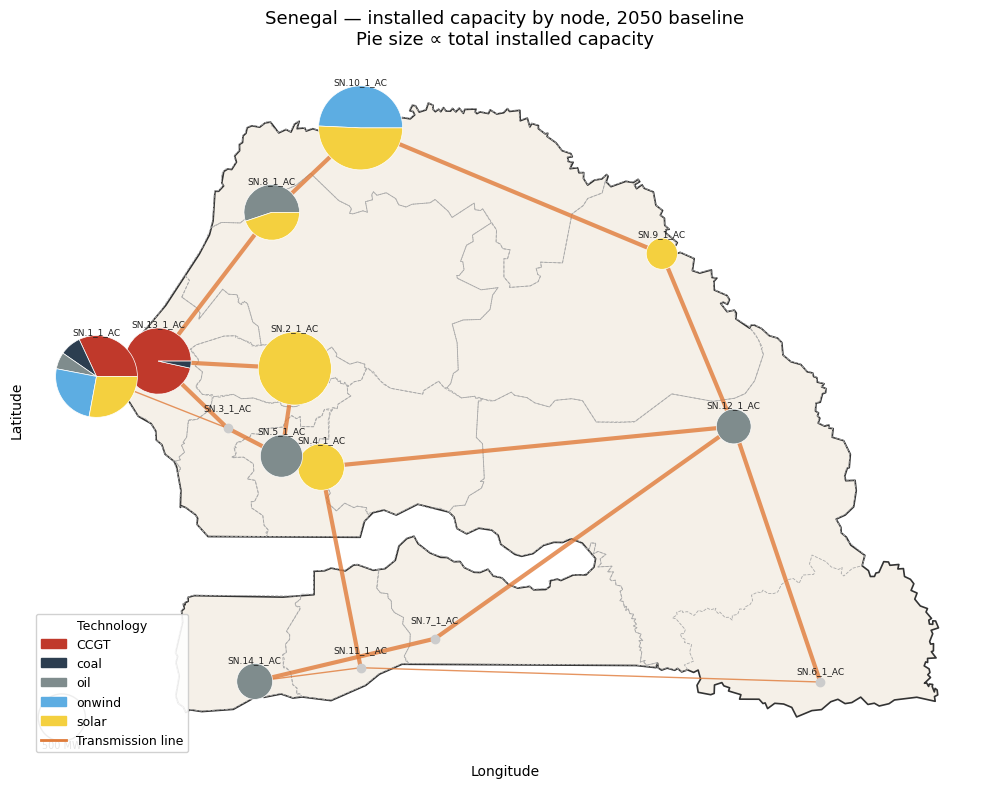

In [27]:
import pypsa
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

SAVE_DIR = "test"
os.makedirs(SAVE_DIR, exist_ok=True)

NETWORK_PATH = "/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc"
REGIONS_PATH = "/Users/william/thesis/pypsa-earth/resources/bus_regions/regions_onshore_elec_s_14.geojson"
SHAPES_PATH  = "/Users/william/thesis/pypsa-earth/resources/shapes/country_shapes.geojson"

n = pypsa.Network(NETWORK_PATH)
regions   = gpd.read_file(REGIONS_PATH)
countries = gpd.read_file(SHAPES_PATH)
senegal   = countries[countries.geometry.intersects(regions.unary_union)]

# total installed capacity per bus
bus_capacity = n.generators.groupby("bus")["p_nom_opt"].sum()

carrier_colors = {
    "solar":   "#f4d03f",
    "onwind":  "#5dade2",
    "oil":     "#7f8c8d",
    "OCGT":    "#e74c3c",
    "CCGT":    "#c0392b",
    "coal":    "#2c3e50",
    "biomass": "#27ae60",
    "hydro":   "#1a5276",
}

fig, ax = plt.subplots(figsize=(10, 8))

senegal.plot(ax=ax, color="#f5f0e8", edgecolor="#333333", linewidth=1.2, zorder=1)
regions.plot(ax=ax, color="none", edgecolor="#aaaaaa", linewidth=0.6, linestyle="--", zorder=2)

# transmission lines (thickness = s_nom)
for _, line in n.lines.iterrows():
    b0 = n.buses.loc[line.bus0]
    b1 = n.buses.loc[line.bus1]
    lw = 1 + 4 * line.s_nom / n.lines.s_nom.max()
    ax.plot([b0.x, b1.x], [b0.y, b1.y],
            color="#e07b39", linewidth=lw, zorder=3, solid_capstyle="round", alpha=0.8)

# pie chart per bus showing capacity mix
present_carriers = set()
max_cap = bus_capacity.max()

for bus_id, bus in n.buses.iterrows():
    gens = n.generators[n.generators.bus == bus_id]
    sizes = gens.groupby("carrier")["p_nom_opt"].sum()
    sizes = sizes[sizes > 1]
    sizes = sizes[sizes.index != "load shedding"]  # exclude safety valve


    cap = bus_capacity.get(bus_id, 0)
    radius = 0.05 + 0.25 * (cap / max_cap) ** 0.5  # scale radius by capacity

    if not sizes.empty:
        present_carriers |= set(sizes.index)
        colors = [carrier_colors.get(c, "#bdc3c7") for c in sizes.index]
        wedges, _ = ax.pie(sizes.values, center=(bus.x, bus.y), radius=radius,
                       colors=colors, wedgeprops=dict(linewidth=0.5, edgecolor="white"))
        for w in wedges:
          w.set_zorder(5)

    else:
        # bus with no generation — plot as grey dot
        ax.plot(bus.x, bus.y, "o", color="#cccccc", markersize=6, zorder=5)

    ax.annotate(bus_id, (bus.x, bus.y + radius + 0.01),
                ha="center", fontsize=6.5, color="#222222", zorder=6)

# legend: carriers
legend_patches = [mpatches.Patch(color=carrier_colors.get(c, "#bdc3c7"), label=c)
                  for c in sorted(present_carriers)]
legend_patches.append(plt.Line2D([0], [0], color="#e07b39", linewidth=2, label="Transmission line"))
ax.legend(handles=legend_patches, loc="lower left", fontsize=9,
          framealpha=0.9, title="Technology", title_fontsize=9)

# reference circle for scale
ref_mw = 500
ref_r  = 0.05 + 0.25 * (ref_mw / max_cap) ** 0.5
ref_circle = plt.Circle((-17.6, 12.3), ref_r, color="none", ec="#555555", lw=1)
ax.add_patch(ref_circle)
ax.annotate(f"{ref_mw} MW", (-17.6, 12.3 - ref_r - 0.05), ha="center", fontsize=7)

ax.set_title("Senegal — installed capacity by node, 2050 baseline\nPie size ∝ total installed capacity",
             fontsize=13, pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
bounds = senegal.total_bounds  # [minx, miny, maxx, maxy]
ax.set_xlim(bounds[0] - 0.3, bounds[2] + 0.3)
ax.set_ylim(bounds[1] - 0.3, bounds[3] + 0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "network_nodes_2050.png"), dpi=150, bbox_inches="tight")
plt.show()


INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads


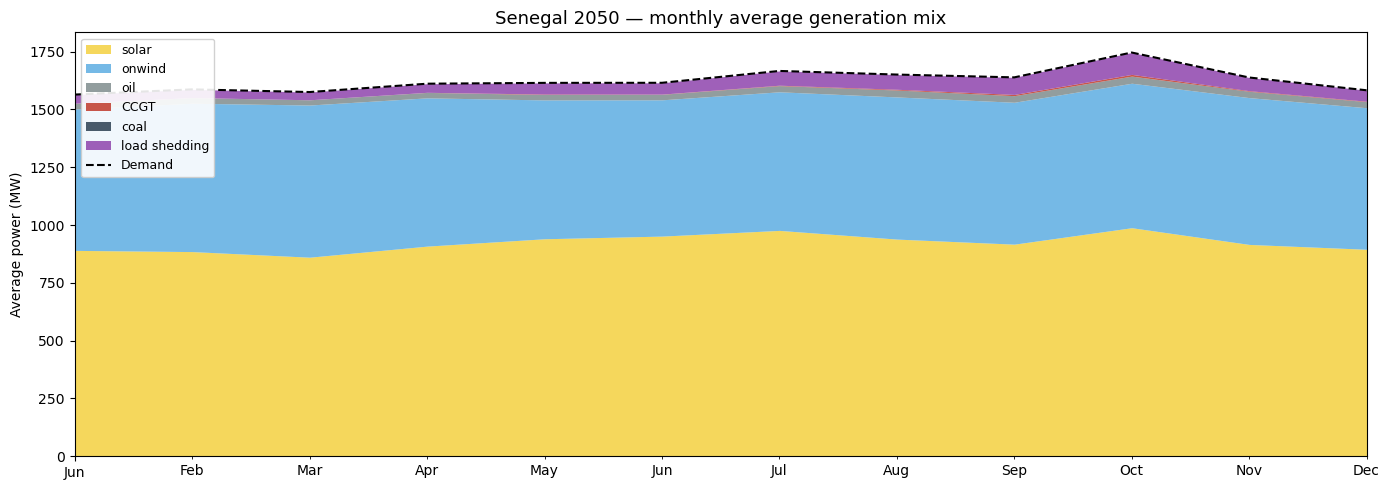

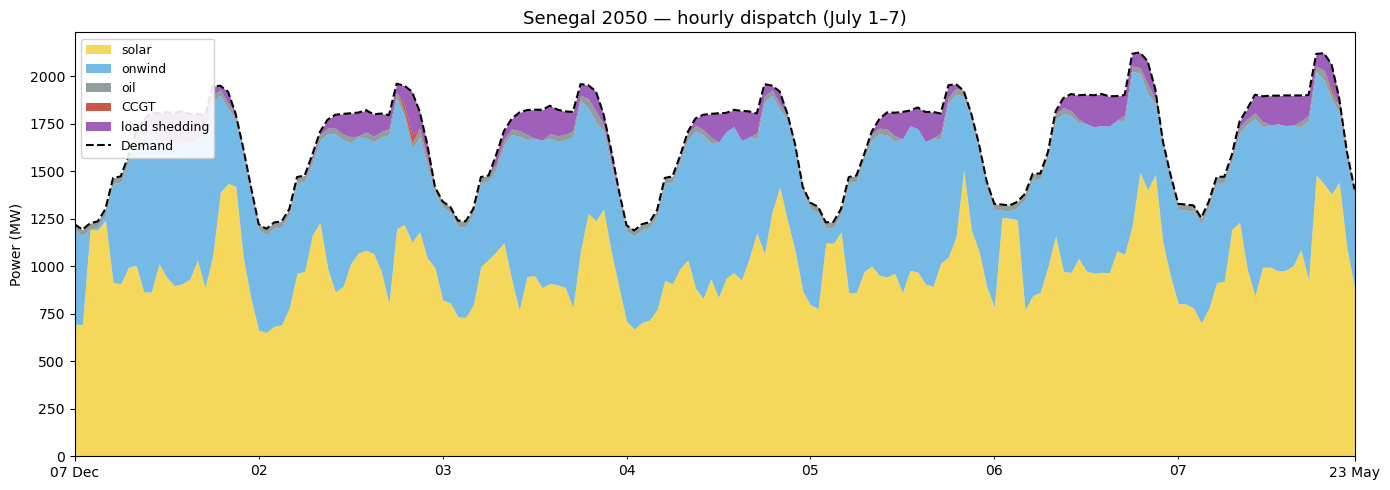

In [35]:
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

SAVE_DIR = "test"
os.makedirs(SAVE_DIR, exist_ok=True)

NETWORK_PATH = "/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc"

n = pypsa.Network(NETWORK_PATH)

carrier_colors = {
    "solar":         "#f4d03f",
    "onwind":        "#5dade2",
    "oil":           "#7f8c8d",
    "OCGT":          "#e74c3c",
    "CCGT":          "#c0392b",
    "coal":          "#2c3e50",
    "biomass":       "#27ae60",
    "hydro":         "#1a5276",
    "load shedding": "#8e44ad",
}

# aggregate generation by carrier across all buses
gen = n.generators_t.p.copy()
gen.columns = n.generators.carrier
gen = gen.T.groupby(level=0).sum().T  # sum per carrier

# total load
load = n.loads_t.p_set.sum(axis=1)

# ── Plot 1: full year (monthly averages) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

monthly = gen.resample("ME").mean()
monthly_load = load.resample("ME").mean()

carriers = [c for c in carrier_colors if c in monthly.columns]
colors   = [carrier_colors[c] for c in carriers]

monthly[carriers].plot.area(ax=ax, color=colors, alpha=0.85, linewidth=0)
monthly_load.plot(ax=ax, color="black", linewidth=1.5, linestyle="--", label="Demand")

ax.set_title("Senegal 2050 — monthly average generation mix", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Average power (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "energy_mix_monthly_2050.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: one representative week (hourly) ──────────────────────────────────
week_start = "2013-07-01"
week_end   = "2013-07-07"

gen_week  = gen.loc[week_start:week_end]
load_week = load.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(14, 5))

carriers_week = [c for c in carrier_colors if c in gen_week.columns and gen_week[c].max() > 1]
colors_week   = [carrier_colors[c] for c in carriers_week]

gen_week[carriers_week].plot.area(ax=ax, color=colors_week, alpha=0.85, linewidth=0)
load_week.plot(ax=ax, color="black", linewidth=1.5, linestyle="--", label="Demand")

ax.set_title("Senegal 2050 — hourly dispatch (July 1–7)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Power (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "energy_mix_week_2050.png"), dpi=150, bbox_inches="tight")
plt.show()


INFO:pypsa.io:Imported network elec_s_14_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, stores
INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads


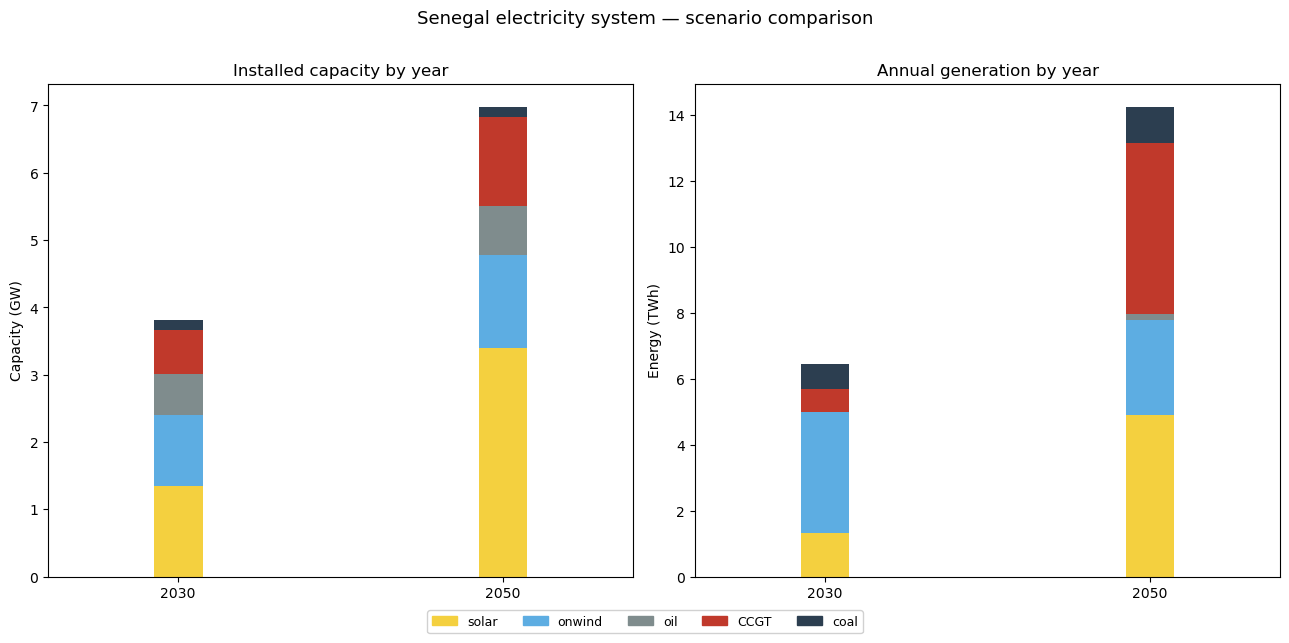

In [26]:
import pypsa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os

SAVE_DIR = "test"
os.makedirs(SAVE_DIR, exist_ok=True)

networks = {
    2030: "/Users/william/thesis/pypsa-earth/results/networks/elec_s_14_ec_lcopt_Co2L-3h.nc",
    2050: "/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc",
}

carrier_colors = {
    "solar":         "#f4d03f",
    "onwind":        "#5dade2",
    "oil":           "#7f8c8d",
    "OCGT":          "#e74c3c",
    "CCGT":          "#c0392b",
    "coal":          "#2c3e50",
    "biomass":       "#27ae60",
    "hydro":         "#1a5276",
    "load shedding": "#8e44ad",
}

# ── collect installed capacity and annual energy per year ─────────────────────
capacity = {}
energy   = {}

for year, path in networks.items():
    n = pypsa.Network(path)
    # exclude load shedding from capacity chart
    gens = n.generators[n.generators.carrier != "load shedding"]
    capacity[year] = gens.groupby("carrier")["p_nom_opt"].sum() / 1e3  # GW

    # annual energy: generation * snapshot weighting (hours)
    gen_t = n.generators_t.p[gens.index]
    weights = n.snapshot_weightings.generators
    energy_yr = (gen_t.multiply(weights, axis=0).sum())   # MWh
    energy_yr.index = n.generators.loc[energy_yr.index, "carrier"]
    energy[year] = energy_yr.groupby(level=0).sum() / 1e6  # TWh

cap_df = pd.DataFrame(capacity).fillna(0)
eng_df = pd.DataFrame(energy).fillna(0)

# only keep carriers that appear in at least one year
carriers = [c for c in carrier_colors if c in cap_df.index]
colors   = [carrier_colors[c] for c in carriers]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# ── left: installed capacity (GW) ─────────────────────────────────────────────
bottom = pd.Series(0.0, index=cap_df.columns)
for carrier, color in zip(carriers, colors):
    if carrier not in cap_df.index:
        continue
    vals = cap_df.loc[carrier]
    ax1.bar(cap_df.columns, vals, bottom=bottom, color=color, label=carrier, width=3)
    bottom += vals

ax1.set_title("Installed capacity by year", fontsize=12)
ax1.set_ylabel("Capacity (GW)")
ax1.set_xticks(list(networks.keys()))
ax1.set_xticklabels([str(y) for y in networks.keys()])
ax1.set_xlim(min(networks.keys()) - 8, max(networks.keys()) + 8)

# ── right: annual energy (TWh) ────────────────────────────────────────────────
bottom = pd.Series(0.0, index=eng_df.columns)
for carrier, color in zip(carriers, colors):
    if carrier not in eng_df.index:
        continue
    vals = eng_df.loc[carrier]
    ax2.bar(eng_df.columns, vals, bottom=bottom, color=color, width=3)
    bottom += vals

ax2.set_title("Annual generation by year", fontsize=12)
ax2.set_ylabel("Energy (TWh)")
ax2.set_xticks(list(networks.keys()))
ax2.set_xticklabels([str(y) for y in networks.keys()])
ax2.set_xlim(min(networks.keys()) - 8, max(networks.keys()) + 8)

# shared legend
patches = [mpatches.Patch(color=carrier_colors[c], label=c) for c in carriers if c in cap_df.index]
fig.legend(handles=patches, loc="lower center", ncol=len(patches),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Senegal electricity system — scenario comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "energy_mix_by_year.png"), dpi=150, bbox_inches="tight")
plt.show()

INFO:pypsa.io:Imported network elec_s_14_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads


Total load shedding: 0.00 TWh/year
Hours with load shedding: 0

Load shedding by bus:
Generator
SN.11_1_AC    0.0
SN.9_1_AC     0.0
SN.4_1_AC     0.0
SN.7_1_AC     0.0
SN.10_1_AC    0.0
SN.3_1_AC     0.0
SN.2_1_AC     0.0
SN.12_1_AC    0.0
SN.13_1_AC    0.0
SN.14_1_AC    0.0
SN.1_1_AC     0.0
SN.5_1_AC     0.0
SN.6_1_AC     0.0
SN.8_1_AC     0.0
dtype: float64


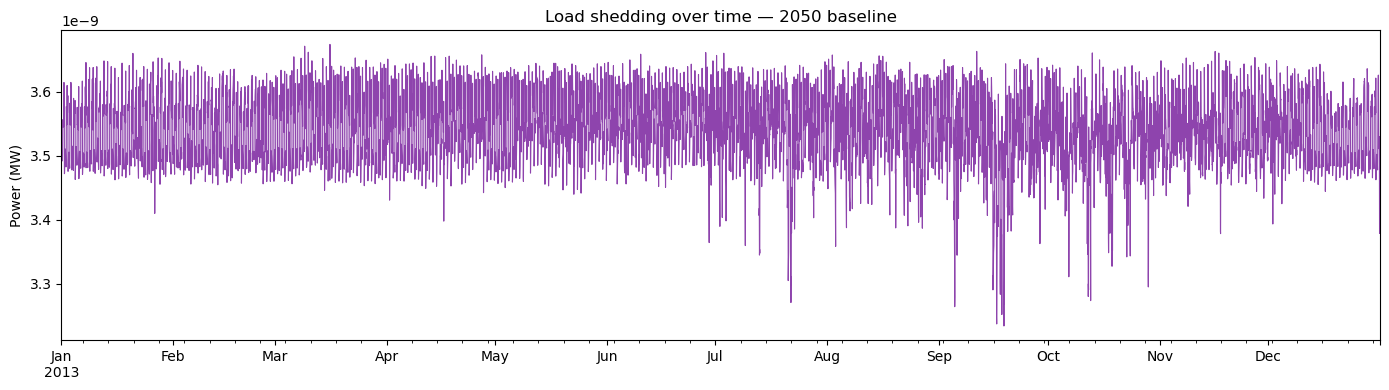

In [28]:
import pypsa
import matplotlib.pyplot as plt
import os

SAVE_DIR = "test"
n = pypsa.Network("/Users/william/thesis/pypsa-earth/results/baseline_no_bess_2050/networks/elec_s_14_ec_lv1.0_1h.nc")

# identify load shedding generators
ls_gens = n.generators[n.generators.carrier == "load shedding"].index
ls = n.generators_t.p[ls_gens]

print(f"Total load shedding: {ls.values.sum() / 1e6:.2f} TWh/year")
print(f"Hours with load shedding: {(ls.sum(axis=1) > 0.1).sum()}")
print(f"\nLoad shedding by bus:")
print(ls.sum().rename(index=lambda x: x.replace(" load shedding", "")).sort_values(ascending=False).round(1))

# plot: load shedding over time
fig, ax = plt.subplots(figsize=(14, 4))
ls.sum(axis=1).plot(ax=ax, color="#8e44ad", linewidth=0.8)
ax.set_title("Load shedding over time — 2050 baseline")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "load_shedding_2050.png"), dpi=150, bbox_inches="tight")
plt.show()


In [19]:
import geopandas as gpd
import pandas as pd
import numpy as np
import json
from shapely.geometry import Point, MultiLineString
import os

# ── paths — update RUN_DIRS to apply to multiple runs ─────────────────────────
BASE = "/Users/william/thesis/pypsa-earth/resources"
RUN_DIRS = [
    "baseline_no_bess_2050",
    "baseline_no_bess_2050_4C",
]

# ── bus ID mapping (clean substation → base network bus) ──────────────────────
# sub_id 5→3, 13→11, 111→9, 133→21, 134→26, 141→25, 148→22
SUB_TO_BASE = {5: 3, 13: 11, 111: 9, 133: 21, 134: 26, 141: 25, 148: 22}

NEW_BUS_LON = -12.183247
NEW_BUS_LAT =  12.553736
NEW_BUS_ID  = 28   # max existing is 27

def haversine_m(lon0, lat0, lon1, lat1):
    R = 6_371_000  # metres
    dlat = np.radians(lat1 - lat0)
    dlon = np.radians(lon1 - lon0)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat0))*np.cos(np.radians(lat1))*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def patch_run(run_dir):
    bn_path = os.path.join(BASE, run_dir, "base_network")
    buses_path = os.path.join(bn_path, "all_buses_build_network.geojson")
    lines_path = os.path.join(bn_path, "all_lines_build_network.geojson")

    buses = gpd.read_file(buses_path)
    lines = gpd.read_file(lines_path)

    # ── 1. add new substation ─────────────────────────────────────────────────
    if NEW_BUS_ID not in buses["bus_id"].values:
        new_bus = {
            "bus_id": NEW_BUS_ID,
            "station_id": NEW_BUS_ID,
            "voltage": 225000,
            "dc": False,
            "symbol": "substation",
            "under_construction": False,
            "tag_substation": "transmission",
            "tag_area": 0.0,
            "lon": NEW_BUS_LON,
            "lat": NEW_BUS_LAT,
            "country": "SN",
            "substation_lv": False,
            "geometry": Point(NEW_BUS_LON, NEW_BUS_LAT),
        }
        buses = pd.concat([buses, gpd.GeoDataFrame([new_bus], crs=buses.crs)], ignore_index=True)
        print(f"[{run_dir}] ✓ Added bus {NEW_BUS_ID} at ({NEW_BUS_LON}, {NEW_BUS_LAT})")
    else:
        print(f"[{run_dir}] Bus {NEW_BUS_ID} already exists — skipping")

    # ── 2. define lines to add ────────────────────────────────────────────────
    new_lines_def = [
        ("custom_sub111_sub134", SUB_TO_BASE[111], SUB_TO_BASE[134]),  # 9 ↔ 26
        ("custom_sub5_sub13",    SUB_TO_BASE[5],   SUB_TO_BASE[13]),   # 3 ↔ 11
        ("custom_sub141_sub148", SUB_TO_BASE[141], SUB_TO_BASE[148]),  # 25 ↔ 22
        ("custom_sub133_new",    SUB_TO_BASE[133], NEW_BUS_ID),        # 21 ↔ 28
    ]

    for line_id, b0, b1 in new_lines_def:
        if line_id in lines["line_id"].values:
            print(f"[{run_dir}] Line {line_id} already exists — skipping")
            continue

        row0 = buses[buses["bus_id"] == b0].iloc[0]
        row1 = buses[buses["bus_id"] == b1].iloc[0]
        length_m = haversine_m(row0.lon, row0.lat, row1.lon, row1.lat)

        new_line = {
            "line_id": line_id,
            "circuits": 1.0,
            "voltage": 225000,
            "bus0": b0,
            "bus1": b1,
            "length": length_m,
            "dc": False,
            "under_construction": False,
            "geometry": MultiLineString([[(row0.lon, row0.lat), (row1.lon, row1.lat)]]),
        }
        lines = pd.concat([lines, gpd.GeoDataFrame([new_line], crs=lines.crs)], ignore_index=True)
        print(f"[{run_dir}] ✓ Added line {line_id}: bus {b0} ↔ bus {b1} ({length_m/1000:.1f} km)")

    # ── 3. save GeoJSON + CSV ─────────────────────────────────────────────────
    buses.to_file(buses_path, driver="GeoJSON")
    lines.to_file(lines_path, driver="GeoJSON")

    # save CSV with geometry as WKT string (required by base_network.py)
    buses_csv = buses.copy()
    buses_csv["geometry"] = buses_csv["geometry"].apply(lambda g: g.wkt)
    buses_csv.to_csv(os.path.join(bn_path, "all_buses_build_network.csv"), index=False)

    lines_csv = lines.copy()
    lines_csv["geometry"] = lines_csv["geometry"].apply(lambda g: g.wkt)
    lines_csv.to_csv(os.path.join(bn_path, "all_lines_build_network.csv"), index=False)

    print(f"[{run_dir}] Saved. Buses: {len(buses)}, Lines: {len(lines)}\n")


# ── run for all specified run directories ─────────────────────────────────────
for run_dir in RUN_DIRS:
    bn_path = os.path.join(BASE, run_dir, "base_network")
    if not os.path.exists(bn_path):
        print(f"[{run_dir}] base_network folder not found — skipping\n")
        continue
    patch_run(run_dir)


INFO:pyogrio._io:Created 29 records
INFO:pyogrio._io:Created 29 records
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/135586360.py:97: UserWarning: Geometry column does not contain geometry.
  buses_csv["geometry"] = buses_csv["geometry"].apply(lambda g: g.wkt)
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/135586360.py:101: UserWarning: Geometry column does not contain geometry.
  lines_csv["geometry"] = lines_csv["geometry"].apply(lambda g: g.wkt)
INFO:pyogrio._io:Created 29 records
INFO:pyogrio._io:Created 29 records


[baseline_no_bess_2050] Bus 28 already exists — skipping
[baseline_no_bess_2050] Line custom_sub111_sub134 already exists — skipping
[baseline_no_bess_2050] Line custom_sub5_sub13 already exists — skipping
[baseline_no_bess_2050] Line custom_sub141_sub148 already exists — skipping
[baseline_no_bess_2050] Line custom_sub133_new already exists — skipping
[baseline_no_bess_2050] Saved. Buses: 29, Lines: 29

[baseline_no_bess_2050_4C] Bus 28 already exists — skipping
[baseline_no_bess_2050_4C] Line custom_sub111_sub134 already exists — skipping
[baseline_no_bess_2050_4C] Line custom_sub5_sub13 already exists — skipping
[baseline_no_bess_2050_4C] Line custom_sub141_sub148 already exists — skipping
[baseline_no_bess_2050_4C] Line custom_sub133_new already exists — skipping
[baseline_no_bess_2050_4C] Saved. Buses: 29, Lines: 29



/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/135586360.py:97: UserWarning: Geometry column does not contain geometry.
  buses_csv["geometry"] = buses_csv["geometry"].apply(lambda g: g.wkt)
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/135586360.py:101: UserWarning: Geometry column does not contain geometry.
  lines_csv["geometry"] = lines_csv["geometry"].apply(lambda g: g.wkt)


In [18]:
import geopandas as gpd
buses = gpd.read_file("/Users/william/thesis/pypsa-earth/resources/baseline_no_bess_2050/base_network/all_buses_build_network.geojson")
lines = gpd.read_file("/Users/william/thesis/pypsa-earth/resources/baseline_no_bess_2050/base_network/all_lines_build_network.geojson")
print(f"Buses: {len(buses)} (expected 29)")
print(f"Lines: {len(lines)} (expected 29)")
print(lines[lines["line_id"].str.startswith("custom")][["line_id","bus0","bus1","length"]])


Buses: 29 (expected 29)
Lines: 29 (expected 29)
                 line_id  bus0  bus1         length
25  custom_sub111_sub134     9    26   54887.827980
26     custom_sub5_sub13     3    11   58652.891617
27  custom_sub141_sub148    25    22  162288.026778
28     custom_sub133_new    21    28  215582.058037


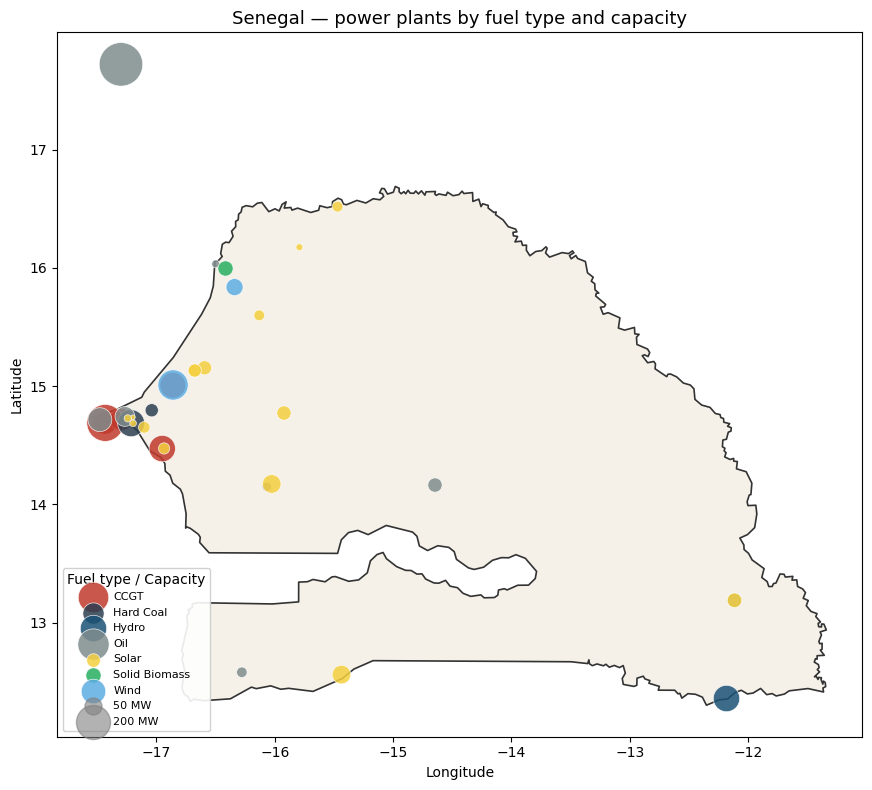

In [31]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

powerplants = pd.read_csv("resources/powerplants.csv", index_col=0)
country_shapes = gpd.read_file("resources/baseline_no_bess_2050/shapes/country_shapes.geojson")

fuel_colors = {
    "Solar": "#f4d03f",
    "Wind": "#5dade2",
    "Oil": "#7f8c8d",
    "CCGT": "#c0392b",
    "Hard Coal": "#2c3e50",
    "Solid Biomass": "#27ae60",
    "Hydro": "#1a5276",
}

fig, ax = plt.subplots(figsize=(10, 8))

country_shapes.plot(ax=ax, color="#f5f0e8", edgecolor="#333333", linewidth=1.2, zorder=1)

for fuel, group in powerplants.groupby("Fueltype"):
    ax.scatter(
        group["lon"], group["lat"],
        s=group["Capacity"] * 3,          # marker area ~ capacity
        color=fuel_colors.get(fuel, "#bdc3c7"),
        edgecolor="white", linewidth=0.5,
        alpha=0.85, zorder=5, label=fuel,
    )

ax.set_title("Senegal — power plants by fuel type and capacity", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(title="Fuel type", fontsize=9, framealpha=0.9, loc="lower left")

# reference bubble sizes for capacity
for cap in [50, 200]:
    ax.scatter([], [], s=cap * 3, color="grey", alpha=0.6, label=f"{cap} MW")
ax.legend(title="Fuel type / Capacity", fontsize=8, framealpha=0.9, loc="lower left")

plt.tight_layout()
plt.show()



In [32]:
import pandas as pd

powerplants = pd.read_csv("resources/powerplants.csv", index_col=0)

capacity_by_fuel = powerplants.groupby("Fueltype")["Capacity"].sum().sort_values(ascending=False)
total_capacity = powerplants["Capacity"].sum()

print("Installed capacity by fuel type (MW):")
print(capacity_by_fuel.round(1))
print(f"\nTotal installed capacity: {total_capacity:.1f} MW ({total_capacity/1e3:.3f} GW)")
print(f"Number of power plants: {len(powerplants)}")


Installed capacity by fuel type (MW):
Fueltype
CCGT             646.0
Oil              609.0
Solar            400.3
Wind             208.0
Hard Coal        155.0
Hydro            120.0
Solid Biomass     40.0
Name: Capacity, dtype: float64

Total installed capacity: 2178.3 MW (2.178 GW)
Number of power plants: 34


/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/2816423760.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(regions))(range(len(regions)))
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/2816423760.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(regions))(range(len(regions)))
/var/folders/2m/6jtrps0d7n9gs5v3067trbzw0000gn/T/ipykernel_2875/2816423760.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.g

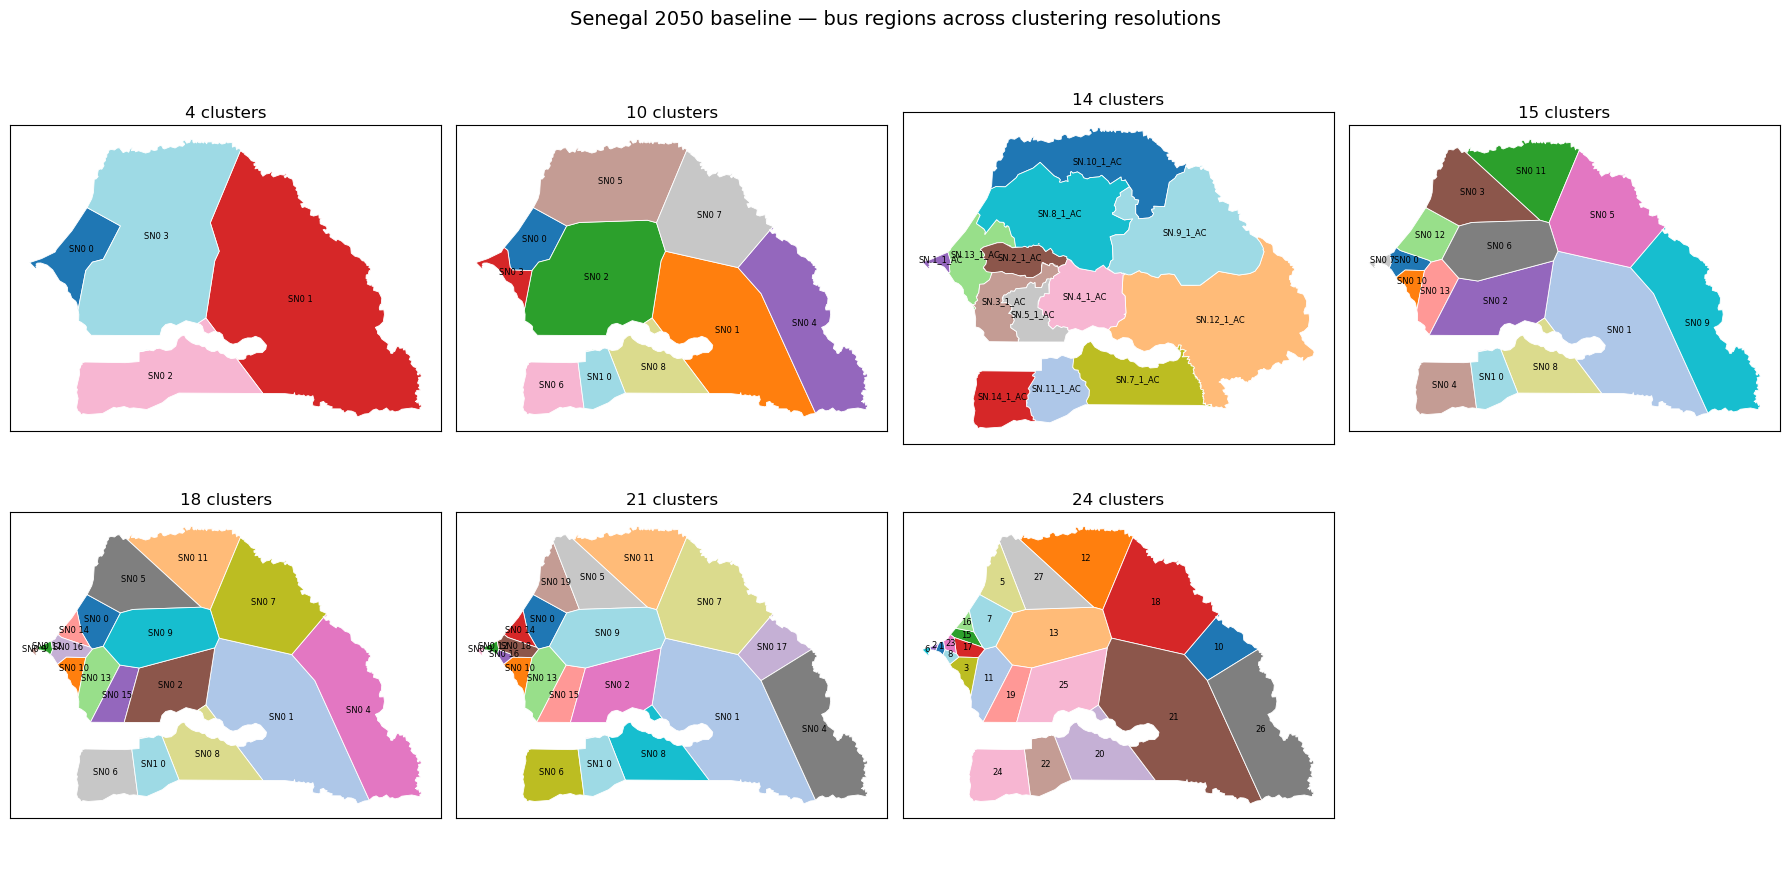

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# cluster count -> (regions geojson, run resource dir)
runs = {
    4:  "resources/baseline_no_bess_2050_4C/bus_regions/regions_onshore_elec_s_4.geojson",
    10: "resources/baseline_no_bess_2050_10C/bus_regions/regions_onshore_elec_s_10.geojson",
    14: "resources/baseline_no_bess_2050/bus_regions/regions_onshore_elec_s_14.geojson",
    15: "resources/baseline_no_bess_2050_therest/bus_regions/regions_onshore_elec_s_15.geojson",
    18: "resources/baseline_no_bess_2050_therest/bus_regions/regions_onshore_elec_s_18.geojson",
    21: "resources/baseline_no_bess_2050_therest/bus_regions/regions_onshore_elec_s_21.geojson",
    24: "resources/baseline_no_bess_2050_therest/bus_regions/regions_onshore_elec_s_24.geojson",
}

n_cols = 4
n_rows = -(-len(runs) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

for ax, (clusters, path) in zip(axes, runs.items()):
    regions = gpd.read_file(path)

    # give each region a distinct color from a categorical colormap
    colors = cm.get_cmap("tab20", len(regions))(range(len(regions)))

    regions.plot(ax=ax, color=colors, edgecolor="white", linewidth=0.6)

    # label each region at its centroid with the bus/cluster id
    for _, row in regions.iterrows():
        c = row.geometry.centroid
        ax.annotate(str(row.get("name", "")), (c.x, c.y),
                    ha="center", fontsize=6, color="black")

    ax.set_title(f"{clusters} clusters", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

# hide any unused subplot axes
for ax in axes[len(runs):]:
    ax.axis("off")

fig.suptitle("Senegal 2050 baseline — bus regions across clustering resolutions", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

